In [17]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split
from torch.backends import cudnn
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  
import torch._dynamo  
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.verbose = False        
import time
import random
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)


Using device: cuda
CUDA Available: True, Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
2.10.0+cu130
True


In [18]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [19]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


In [20]:
torch.backends.cudnn.benchmark = True          # Huge speedup on fixed input size (256×256)
torch.backends.cuda.matmul.allow_tf32 = True   # +15–20% speed on Ampere/Ada (4060)
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')     # Use TensorFloat-32 where possible
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   

# DATA

In [21]:
# import importlib
# import dataset
# # import testdataset
# importlib.reload(dataset)
# # importlib.reload(testdataset)
# # from traindataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path, transform as train_transform
# from dataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path


In [22]:
# train_transform = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.Pad(8, fill=255, padding_mode='constant'),
#     transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.92, 1.08), fill=255),
#     transforms.RandomPerspective(distortion_scale=0.1, p=0.25, fill=255),
#     transforms.RandomApply(
#         [transforms.GaussianBlur(3, sigma=(0.1, 0.5))],
#         p=0.3
#     ),
#     transforms.Resize((64, 64)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,)),# <-- randomly erase patches
#     # transforms.RandomErasing(p=0.05, scale=(0.02,0.05), ratio=(0.3,3.3))  
# ])

# test_transform= transforms.Compose([
#     transforms.Resize((64, 64)),  # Resize to match FashionMNIST if needed
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))  # Standard normalization
# ])

# class TransformedDataset(Dataset):
#     def __init__(self, base_dataset, transform=None):
#         self.base_dataset = base_dataset
#         self.transform = transform

#     def __len__(self):
#         return len(self.base_dataset)

#     def __getitem__(self, idx):
#         img1, img2, label = self.base_dataset[idx]  # Gets PIL images and label from original
#         if self.transform:
#             img1 = self.transform(img1)
#             img2 = self.transform(img2)
#         return img1, img2, label
        

In [23]:

# all_dataset = SignatureVerificationDataset(
#     genuine_dir=genuine_extract_path,
#     forgery_dir=forgery_extract_path,
#     transform=test_transform
# )
# train_size = int(0.6 * len(all_dataset))
# test_size = len(all_dataset) - train_size
# train_dataset, test_dataset = random_split(all_dataset,[train_size,test_size])


# dataloader = DataLoader(
#     train_dataset, 
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=True,
#     num_workers=8,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )


In [24]:
# from testdataset import SignatureVerificationTestDataset, reference_extract_path, ques_extract_path,transform as test_transform

# testdataset = SignatureVerificationTestDataset(
#     reference_extract_path,
#     ques_extract_path,
#     transform=test_transform
# )
# test_size = int(0.6 * len(testdataset))
# val_size = len(testdataset) - test_size

# test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

# val_loader = DataLoader(val_dataset,
#                         batch_size=128,           # or 192/256 now that you use 64×64 images
#                         shuffle=False,
#                         num_workers=6,            # ← magic number for almost all gaming laptops
#                         pin_memory=True,          # ← very important with GPU
#                         prefetch_factor=2,
#                         persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=128,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )

In [25]:
# print(train_transform,"nrdd",test_transform)
import dataset
import importlib

Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

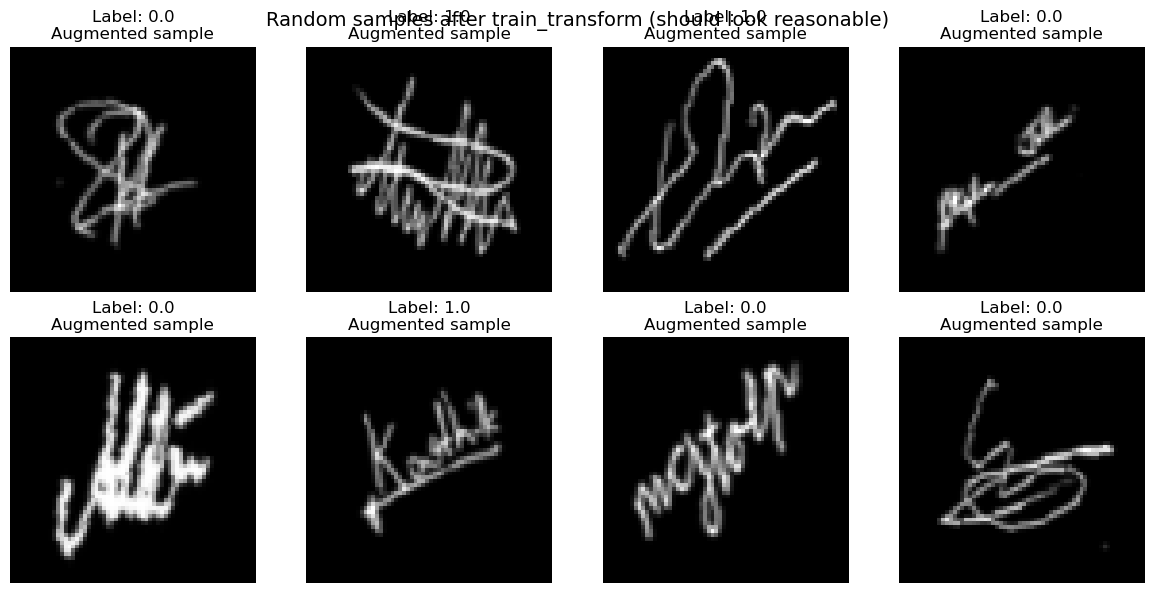

In [96]:
importlib.reload(dataset)
from dataset import train_dataloader,val_dataloader,test_dataloader

In [89]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)  # ✅ 2 channels
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        max_pool = torch.max(x, dim=1, keepdim=True)[0]   # ✅ Max
        avg_pool = torch.mean(x, dim=1, keepdim=True)     # ✅ Average
        combined = torch.cat([max_pool, avg_pool], dim=1) # ✅ Concatenate
        attention = self.sigmoid(self.conv(combined))
        return x * attention
# class SpatialAttention(nn.Module):
#     def __init__(self, kernel_size=7):
#         super(SpatialAttention, self).__init__()
#         # ─── Most important fix ───
#         self.conv = nn.Conv2d(1, 1, kernel_size=kernel_size, padding=kernel_size//2)
#         self.sigmoid = nn.Sigmoid()
    
#     def forward(self, x):
#         # Only max pooling along channel dimension
#         max_pool, _ = torch.max(x, dim=1, keepdim=True)   # shape: [B, 1, H, W]
        
#         # Now conv receives 1 channel → correct
#         attention = self.sigmoid(self.conv(max_pool))     # [B, 1, H, W]
        
#         return x * attention

In [90]:
class SiameseCNN(nn.Module):
    def __init__(self):
        super(SiameseCNN, self).__init__()
        
        # Block 1: 64×64 → 64×64 (no pooling!)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.1)
        )
        
        # Block 2: 64×64 → 32×32
        self.pool1 = nn.MaxPool2d(2)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.15)
        )
        
        # Block 3: 32×32 → 16×16
        self.pool2 = nn.MaxPool2d(2)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.PReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.2)
        )
        
        # Block 4: 16×16 → 8×8
        self.pool3 = nn.MaxPool2d(2)
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.PReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.PReLU(),
            SpatialAttention(),
            nn.Dropout2d(0.2)
        )
        
        # Global pooling: 8×8 → 1×1
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(256, 256),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256)
        )
    
    # ← CRITICAL: These methods must be at the same indentation level as __init__
    def forward_one(self, x):
        """Forward pass for a single image"""
        # Forward through blocks
        x = self.block1(x)      # 64×64×32
        x = self.pool1(x)       # 32×32×32
        
        x = self.block2(x)      # 32×32×64
        x = self.pool2(x)       # 16×16×64
        
        x = self.block3(x)      # 16×16×128
        x = self.pool3(x)       # 8×8×128
        
        x = self.block4(x)      # 8×8×256
        
        x = self.global_pool(x) # 1×1×256
        x = torch.flatten(x, 1) # 256
        
        x = self.embedding(x)   # embedding_dim
        x = F.normalize(x, p=2, dim=1)  # L2 normalize
        return x
    
    def forward(self, x1, x2=None):
        """
        Forward pass for Siamese network
        
        Args:
            x1: First image tensor
            x2: Optional second image tensor
            
        Returns:
            If x2 is None: returns emb1
            If x2 is provided: returns (emb1, emb2)
        """
        emb1 = self.forward_one(x1)
        if x2 is not None:
            emb2 = self.forward_one(x2)
            return emb1, emb2
        return emb1

In [91]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        distance = F.pairwise_distance(emb1, emb2)
        
        # Genuine pairs: minimize distance
        pos_loss = label * torch.pow(distance, 2)
        
        # Forged pairs: maximize distance (up to margin)
        neg_loss = (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0),2)
        loss = pos_loss + neg_loss

        weights = torch.ones_like(loss)
        
        # Hard positives: pairs with large distance
        hard_pos_mask = (label == 1) & (distance > distance[label==1].median())
        weights[hard_pos_mask] = 2.0
        
        # Hard negatives: pairs with small distance
        hard_neg_mask = (label == 0) & (distance < distance[label==0].median())
        weights[hard_neg_mask] = 2.0
        
        loss = loss * weights
    
        return loss.mean()

In [92]:
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
margin=0.6
lr=0.01
threshold=0.7
model=SiameseCNN()
model = torch.compile(model, mode="reduce-overhead")   # or "default"
model = model.to(device)

In [93]:
import torch.optim.lr_scheduler as lr_scheduler
criterion = ContrastiveLoss(margin=margin)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  # AdamW > Adam
scaler = GradScaler()
# After optimizer definition
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # 'min' for minimizing loss; use 'max' if monitoring accuracy
    factor=0.1,       # Multiply lr by this (e.g., 0.0001 → 0.00001)
    patience=10,
    threshold=1e-4,   # Wait this many epochs without improvement
    min_lr=1e-6 # Optional: Minimum lr to stop reducing below
)
best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_margin{margin}_size64_lr{lr}.pt"


In [94]:
# Training with mixed precision
best_val_loss = float('inf')
early_stop_counter = 0
patience = 10
min_delta = 0.0005
num_epochs = 30

for epoch in range(num_epochs):
    # ─── Training ────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    start_time = time.time()

    for img1, img2, labels in train_dataloader:
        img1, img2, labels = (img1.to(device, non_blocking=True),
                              img2.to(device, non_blocking=True),
                              labels.to(device, non_blocking=True))
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
            loss = criterion(emb1, emb2, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        num_batches += 1

    epoch_time = time.time() - start_time
    avg_train_loss = epoch_loss / num_batches
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"LR: {current_lr:.6f}")
    

    # ─── Validation every 2 epochs ───────────────────────────────────
    # ─── Validation every 4 epochs ───────────────────────────────────
    if (epoch + 1) % 1 == 0:
        model.eval()
        val_losses = []
        distance_all = []
        labels_all = []
        
        with torch.no_grad():
            for img1, img2, labels in val_dataloader:
                # Use only first reference
                img1 = img1.to(device, non_blocking=True)
                img2 = img2.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
            
                with autocast("cuda", dtype=torch.bfloat16):
                    emb1 = model(img1)
                    emb2 = model(img2)
            
                distance = F.pairwise_distance(emb1, emb2)
                distance_all.append(distance)
                labels_all.append(labels)
            
                val_batch_loss = criterion(emb1, emb2, labels)
                val_losses.append(val_batch_loss.item())

        # Aggregate
        distance_all = torch.cat(distance_all)
        labels_all = torch.cat(labels_all)
        avg_val_loss = sum(val_losses) / len(val_losses)

        # ─── Threshold tuning (FIXED!) ───────────────────────────────
        y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!
        
        # Method 1: Simple negation approach (recommended)
        similarity_scores = -distance_all.cpu().numpy()
        fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

        eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
        print(f"EER: {eer:.4f}")  # Aim for <0.1 for good models
        y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

        print(f"   Val Loss: {avg_val_loss:.6f} | "
              f"Acc: {accuracy_score(y_true, y_pred):.4f} | "
              f"Threshold: {optimal_threshold:.3f} | "  # ← FIXED variable name
              f"Genuine: {distance_all[labels_all==1].mean():.3f} | "
              f"Forged: {distance_all[labels_all==0].mean():.3f}")
        
        scheduler.step(avg_val_loss)

        # ─── Early Stopping ──────────────────────────────────────────
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   → New best val loss: {best_val_loss:.6f} (saved)")
        else:
            early_stop_counter += 1
            print(f"   → No improvement. Patience: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

        # Cleanup (FIXED!)
        del distance_all, labels_all, y_true, y_pred
        torch.cuda.empty_cache()

# ─── Load best model ─────────────────────────────────────────────────
print("Loading best model for final evaluation...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

Epoch  0/30 | Train Loss: 0.1380 | Time: 172.4s | LR: 0.010000
EER: 0.2626
   Val Loss: 0.148918 | Acc: 0.7388 | Threshold: 0.128 | Genuine: 0.093 | Forged: 0.228
   → New best val loss: 0.148918 (saved)
Epoch  1/30 | Train Loss: 0.1260 | Time: 64.7s | LR: 0.010000
EER: 0.2219
   Val Loss: 0.116912 | Acc: 0.7814 | Threshold: 0.210 | Genuine: 0.135 | Forged: 0.310
   → New best val loss: 0.116912 (saved)
Epoch  2/30 | Train Loss: 0.1129 | Time: 64.2s | LR: 0.010000
EER: 0.2070
   Val Loss: 0.101801 | Acc: 0.7973 | Threshold: 0.242 | Genuine: 0.163 | Forged: 0.397
   → New best val loss: 0.101801 (saved)
Epoch  3/30 | Train Loss: 0.1024 | Time: 63.8s | LR: 0.010000
EER: 0.1996
   Val Loss: 0.097292 | Acc: 0.8050 | Threshold: 0.258 | Genuine: 0.163 | Forged: 0.406
   → New best val loss: 0.097292 (saved)
Epoch  4/30 | Train Loss: 0.0887 | Time: 63.8s | LR: 0.010000
EER: 0.1992
   Val Loss: 0.099674 | Acc: 0.8076 | Threshold: 0.228 | Genuine: 0.150 | Forged: 0.383
   → No improvement. Pati

KeyboardInterrupt: 

Starting saliency map analysis...
✓ Collected 5 genuine and 5 forged pairs

Visualizing GENUINE pairs (model should focus on stroke similarities)
Processing genuine pair 1/5...


C:\Users\gupta\7th SEM\Project\Signature\saliency_visualization.py:385: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: saliency_outputs/pair_0_genuine pair_dist0.259.png


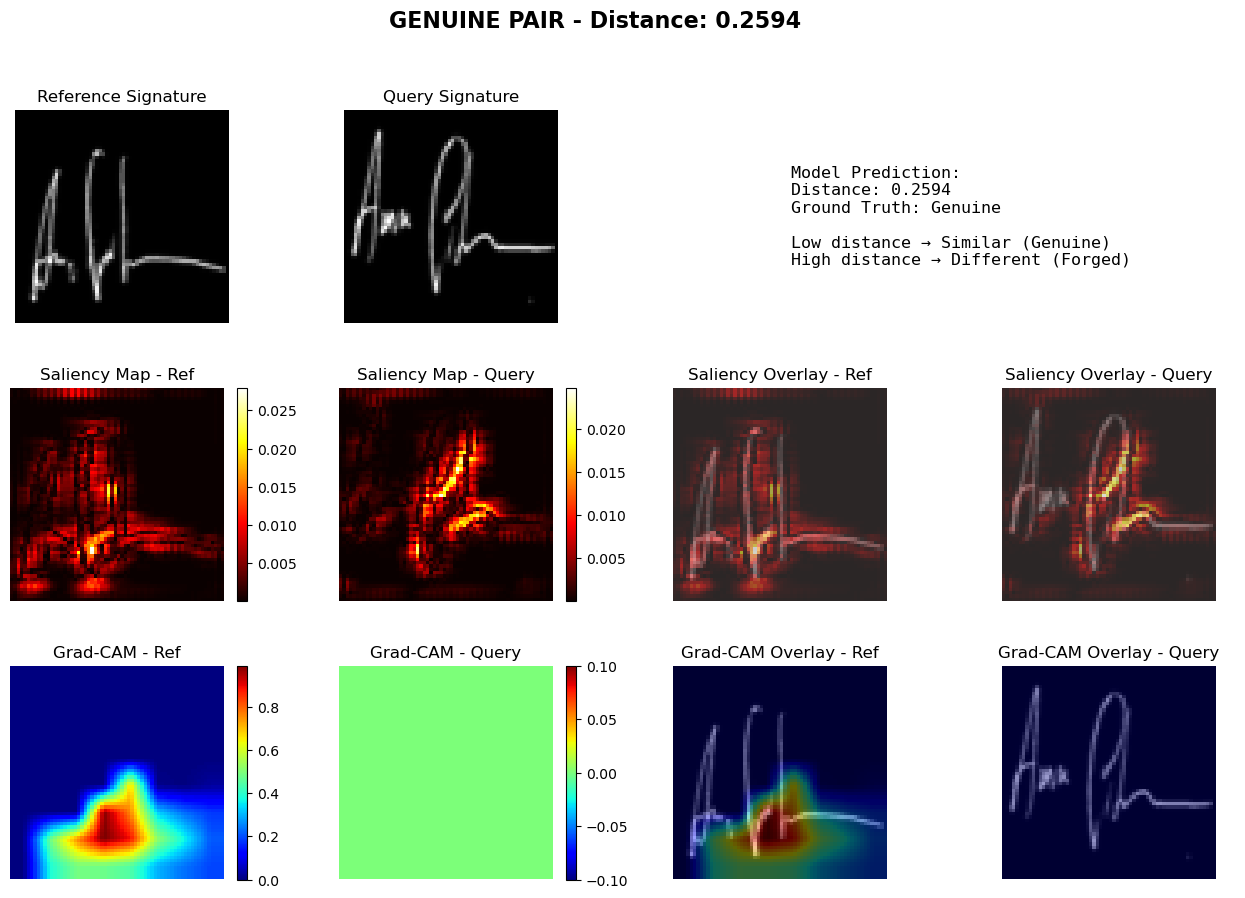

Processing genuine pair 2/5...
Saved: saliency_outputs/pair_1_genuine pair_dist0.266.png


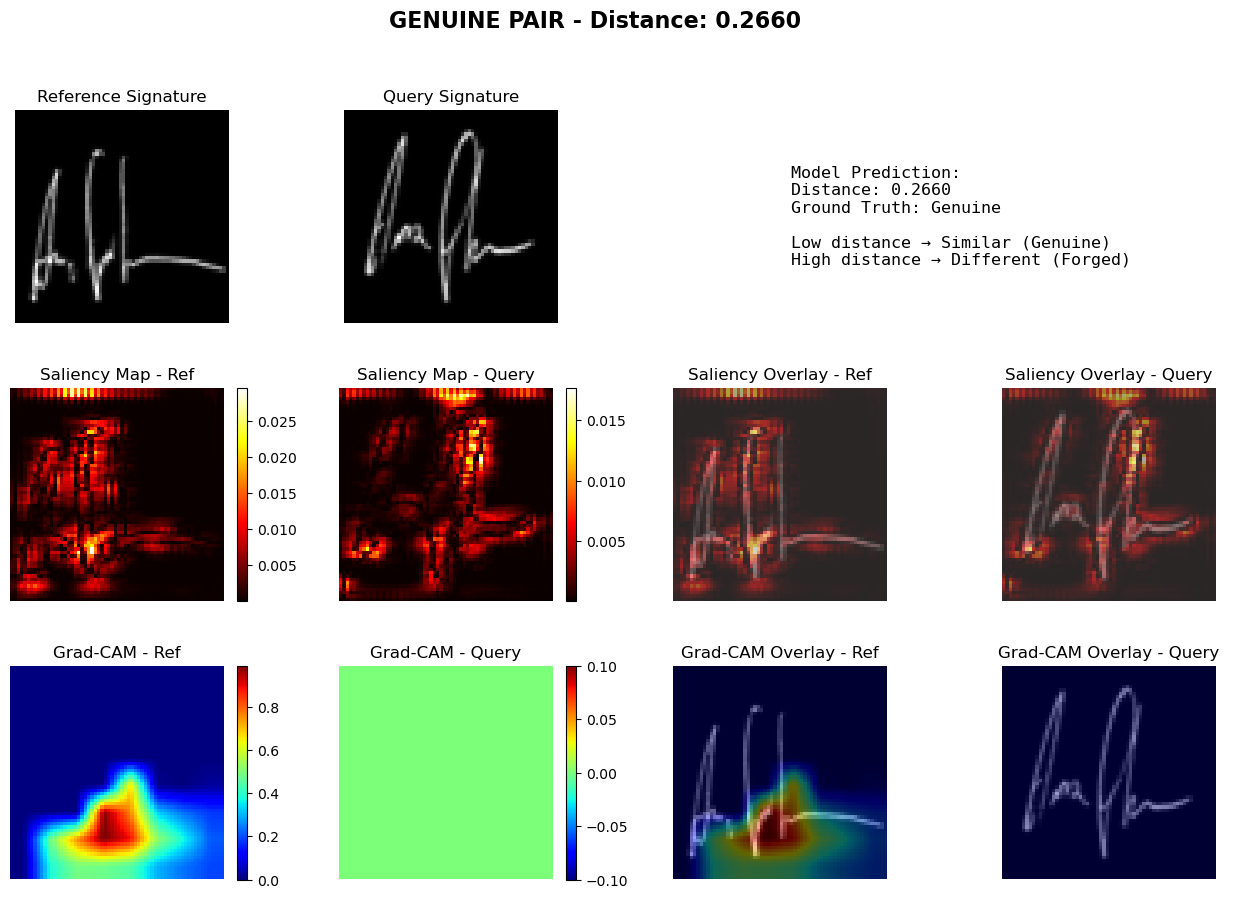

Processing genuine pair 3/5...
Saved: saliency_outputs/pair_2_genuine pair_dist0.193.png


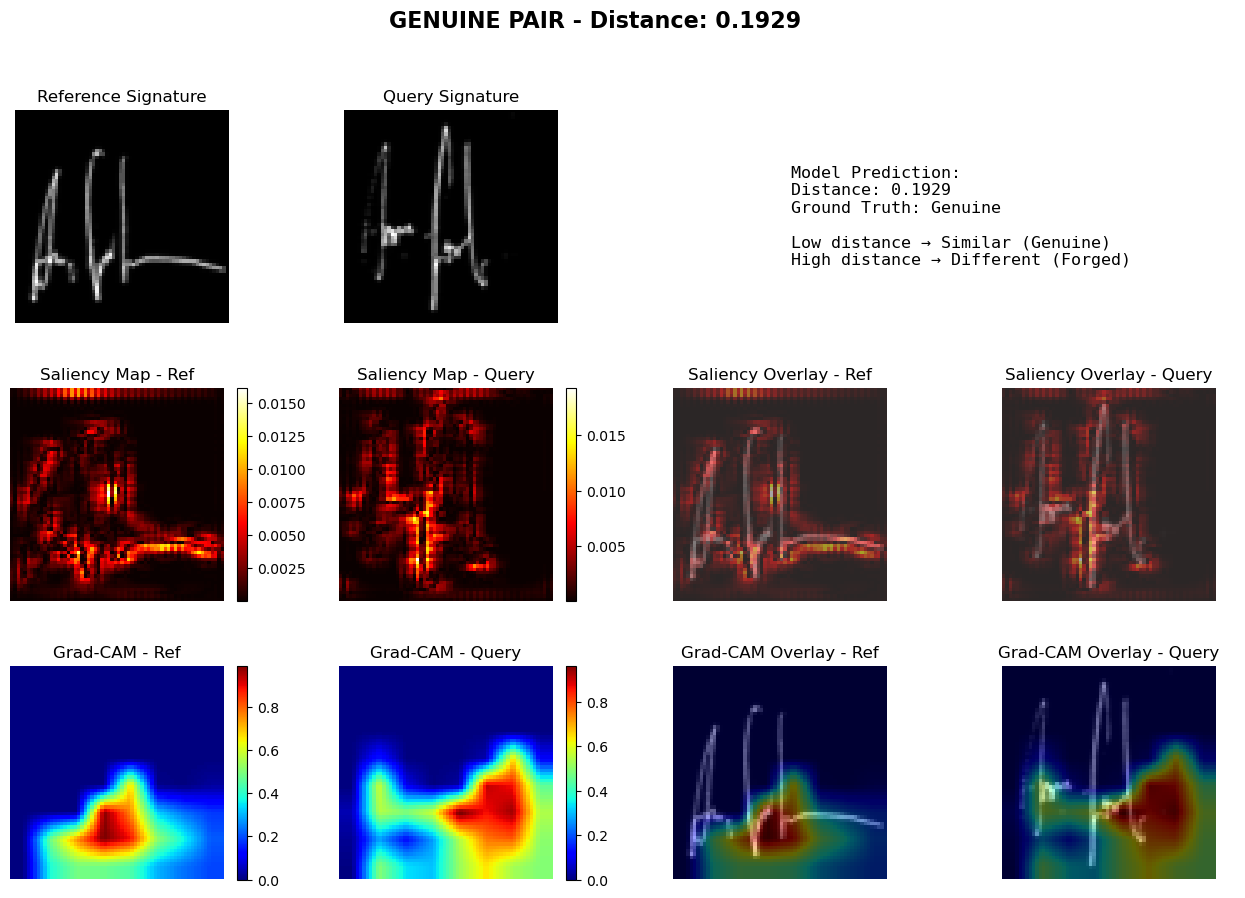

Processing genuine pair 4/5...
Saved: saliency_outputs/pair_3_genuine pair_dist0.209.png


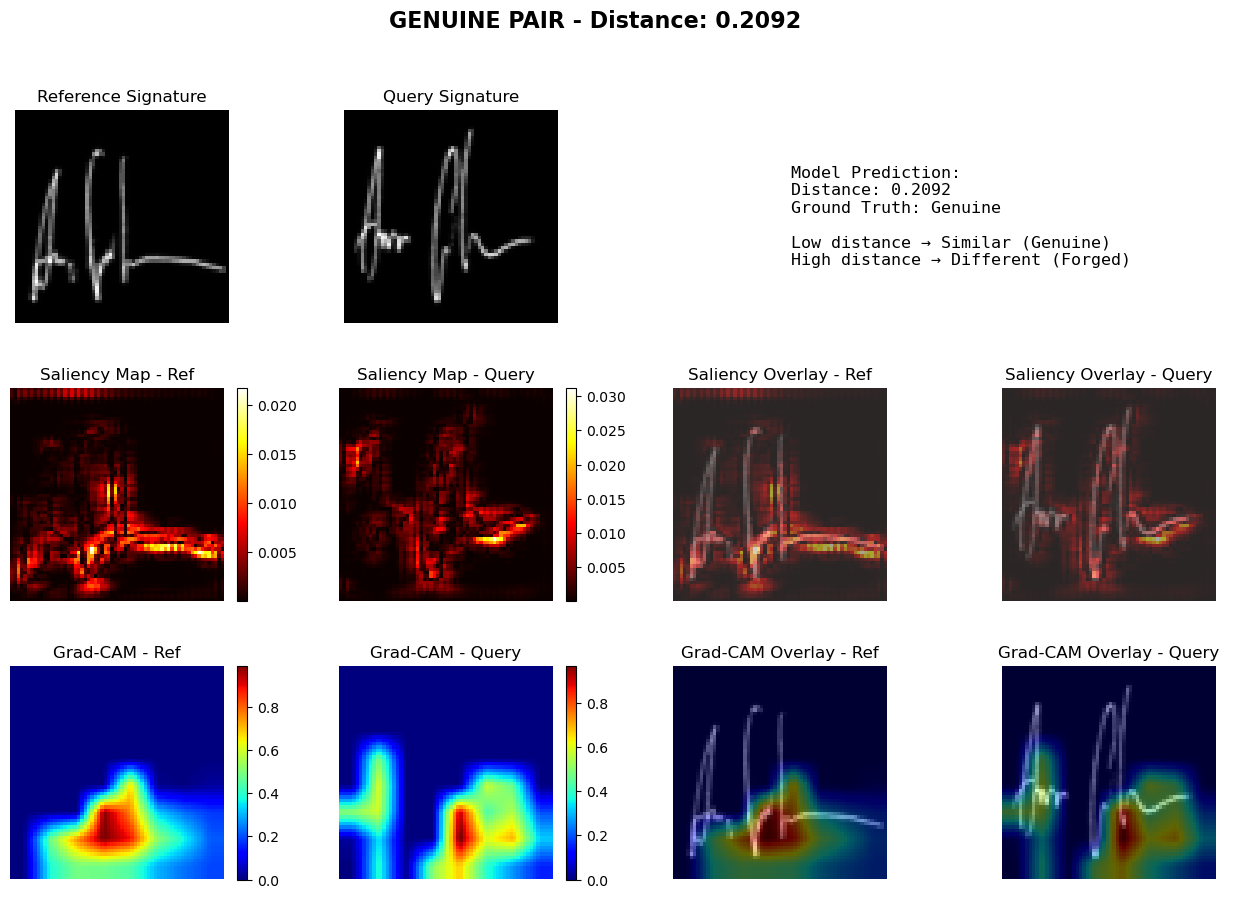

Processing genuine pair 5/5...
Saved: saliency_outputs/pair_4_genuine pair_dist0.198.png


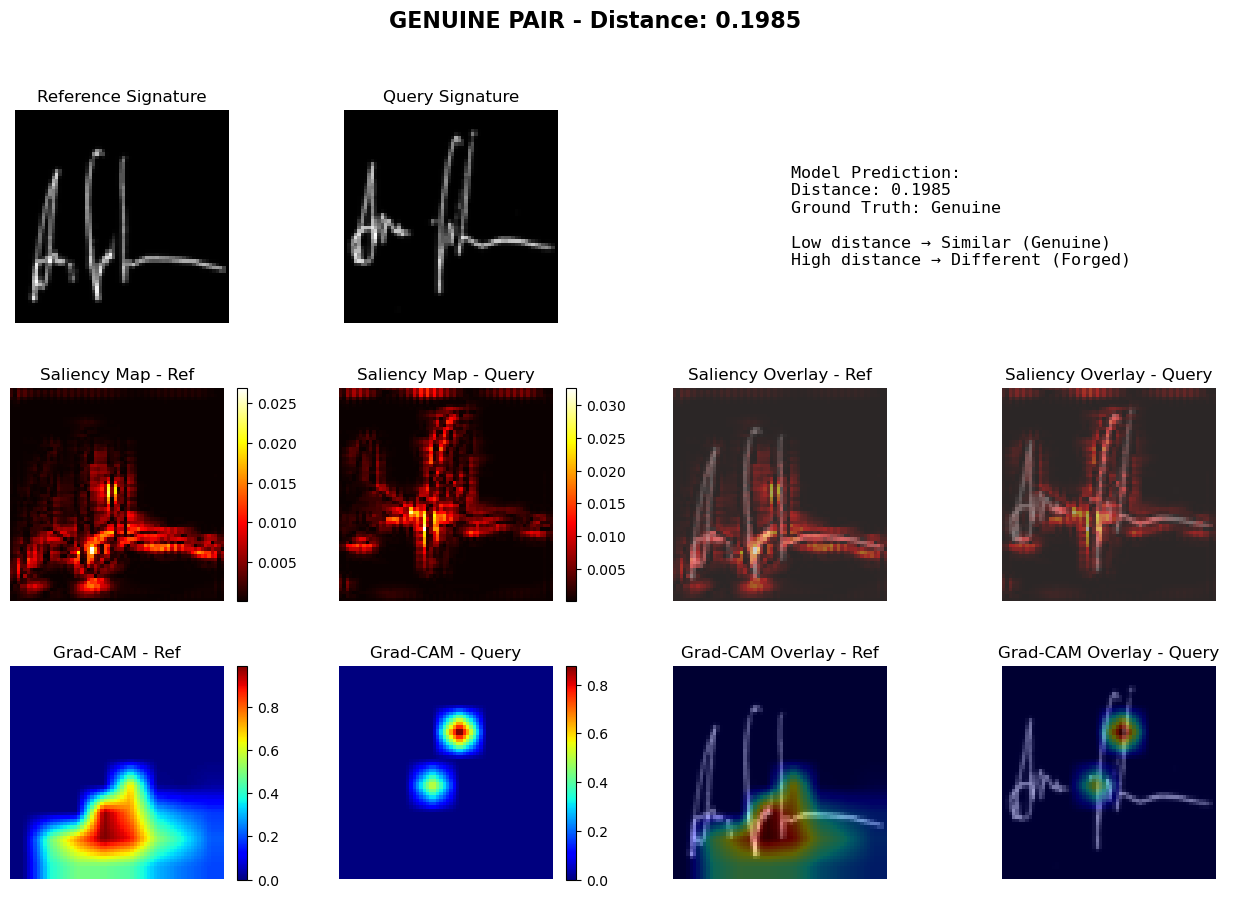


Visualizing FORGED pairs (model should detect differences)
Processing forged pair 1/5...
Saved: saliency_outputs/pair_5_forged pair_dist0.190.png


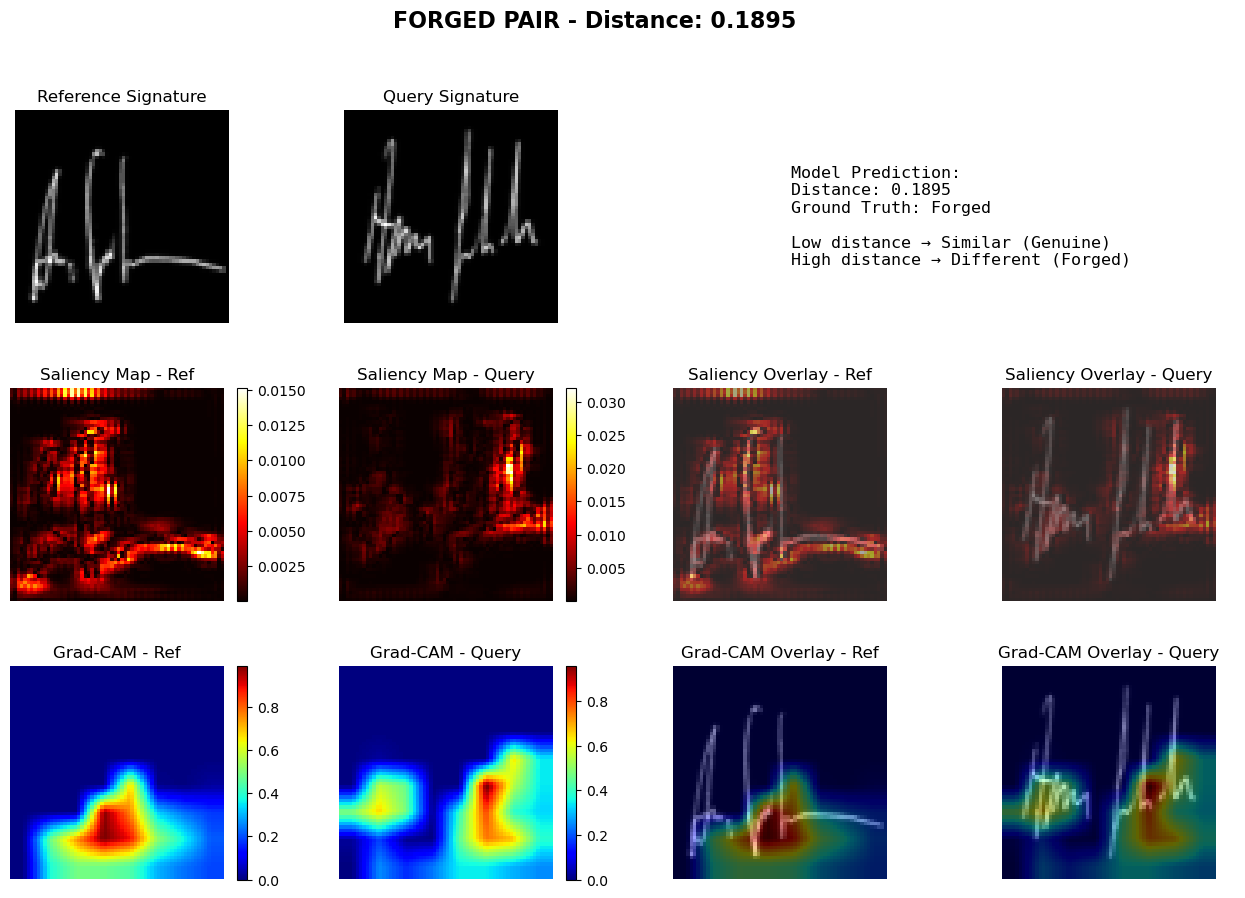

Processing forged pair 2/5...
Saved: saliency_outputs/pair_6_forged pair_dist0.235.png


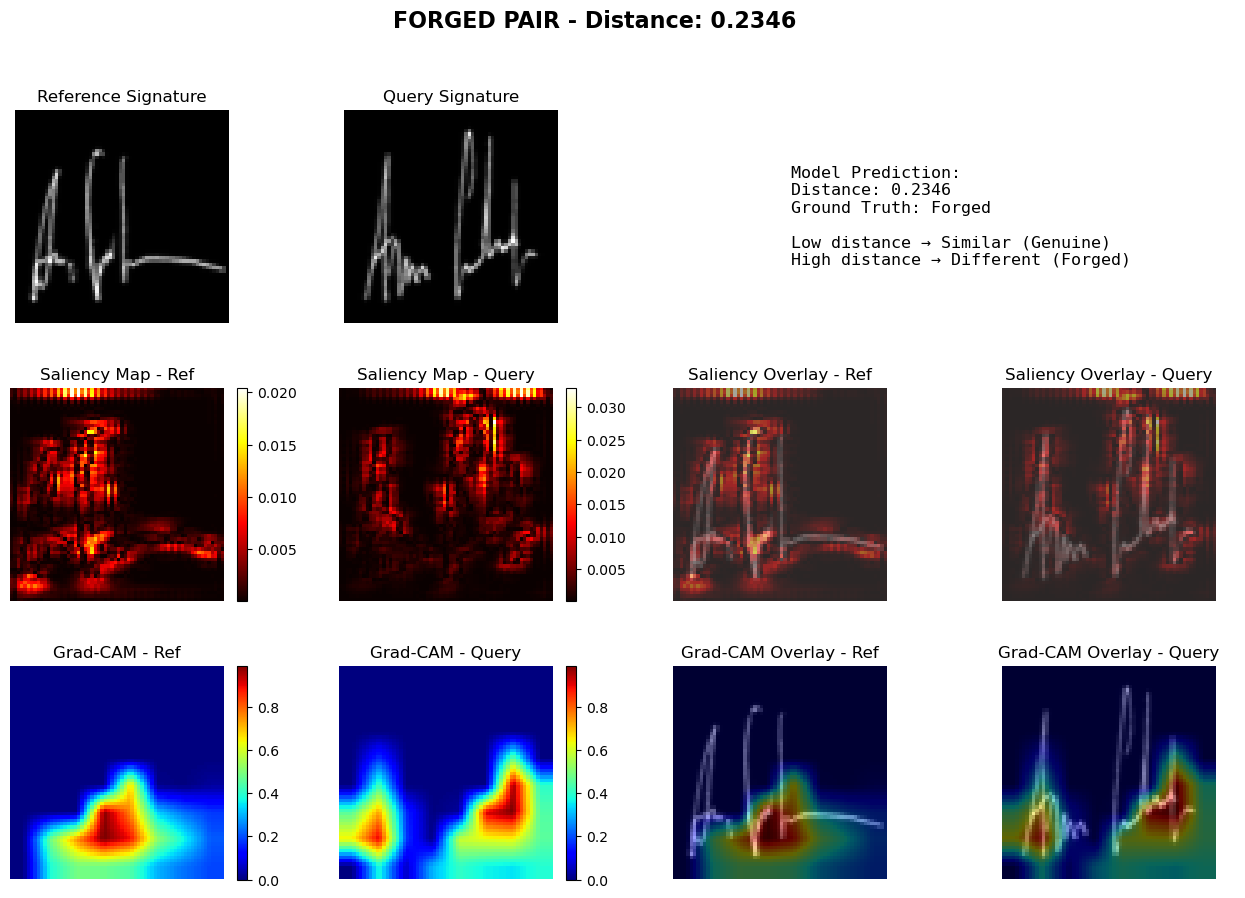

Processing forged pair 3/5...
Saved: saliency_outputs/pair_7_forged pair_dist0.219.png


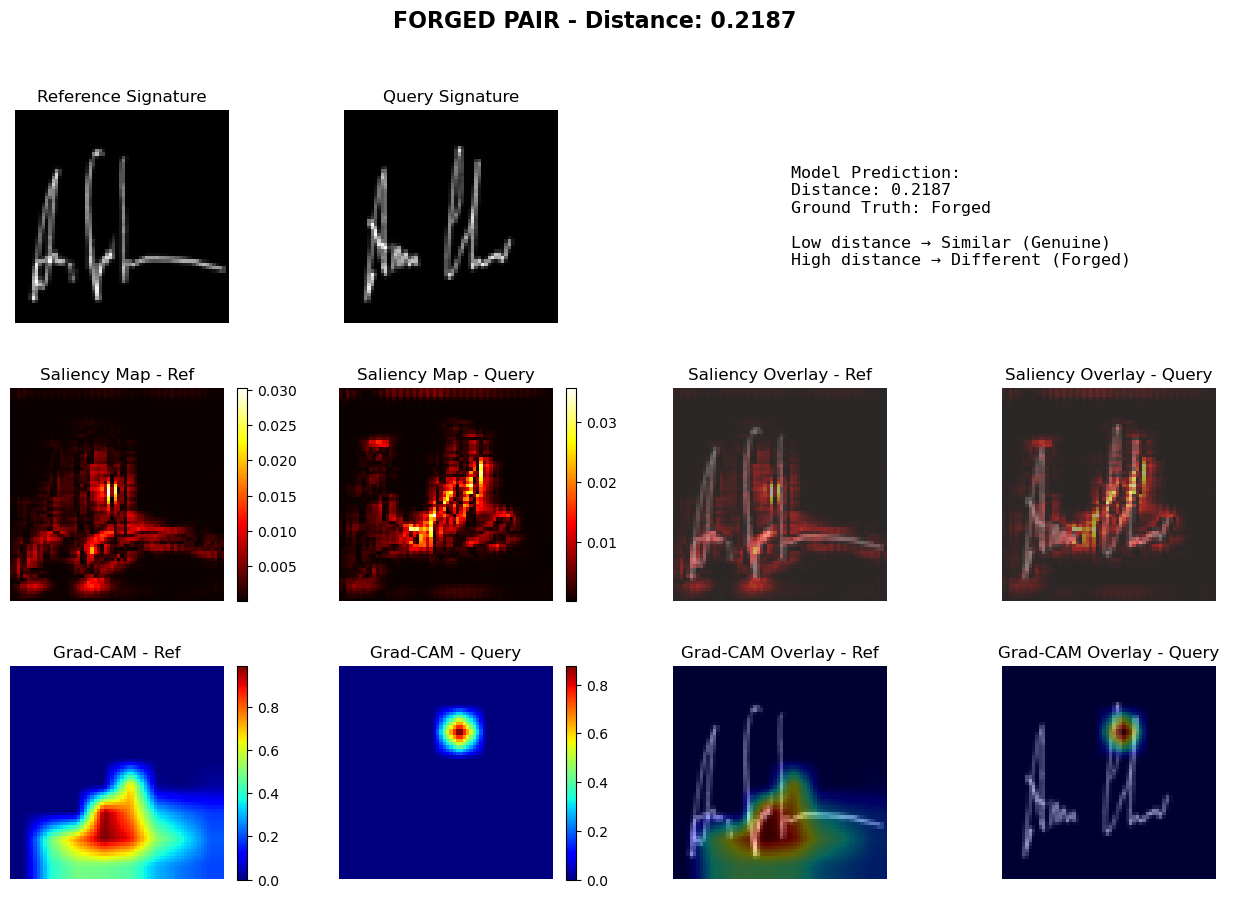

Processing forged pair 4/5...
Saved: saliency_outputs/pair_8_forged pair_dist0.268.png


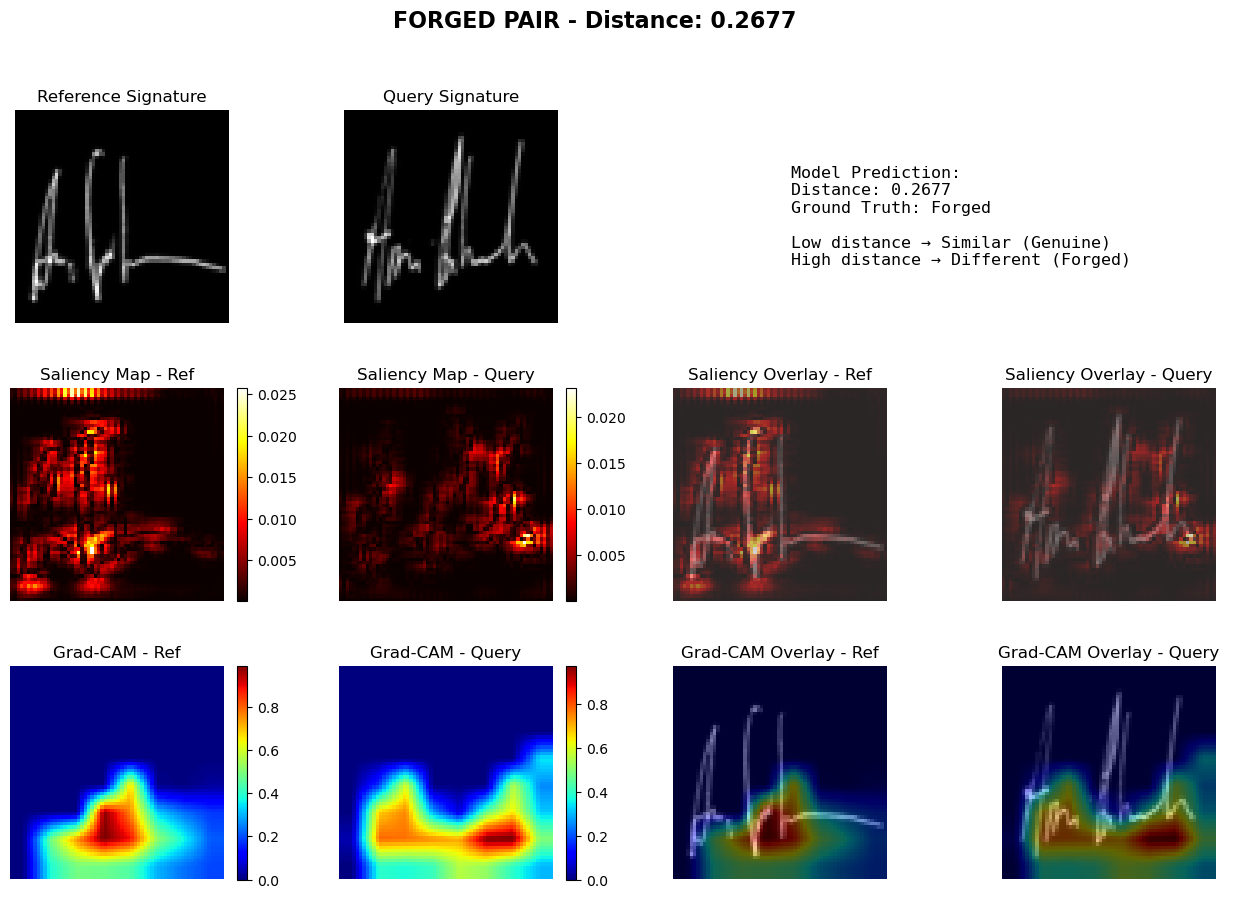

Processing forged pair 5/5...
Saved: saliency_outputs/pair_9_forged pair_dist0.223.png


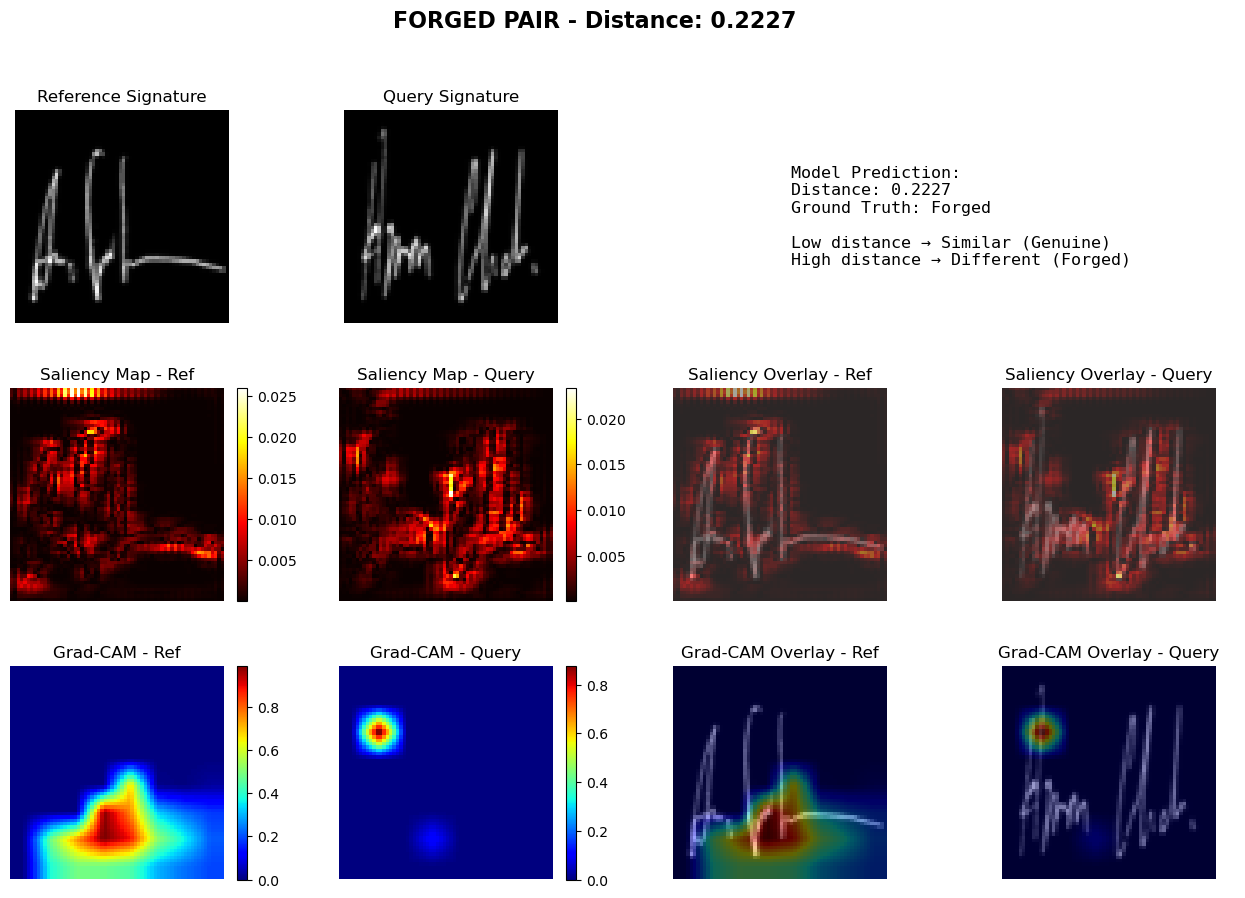


✓ All visualizations saved to: saliency_outputs

HOW TO INTERPRET THE VISUALIZATIONS:

    1. SALIENCY MAPS (Hot colors):
       - Show which pixels have the most influence on the model's decision
       - For genuine pairs: Should highlight stroke patterns that match
       - For forged pairs: Should highlight areas where signatures differ
    
    2. GRAD-CAM (Jet colors):
       - Shows which regions the CNN's last conv layer is focusing on
       - Red/yellow = high activation (model is "looking" here)
       - Blue = low activation (model ignores this area)
       - Good model: Focuses on signature strokes, not background
    
    3. WHAT TO LOOK FOR:
       ✓ Model focuses on actual signature strokes (not edges of image)
       ✓ Saliency highlights distinctive writing patterns
       ✓ Similar focus areas for genuine pairs
       ✓ Different focus areas for forged pairs
       
       ✗ Model focuses on image corners/edges (it's learning artifacts)
       ✗ Random scattered act

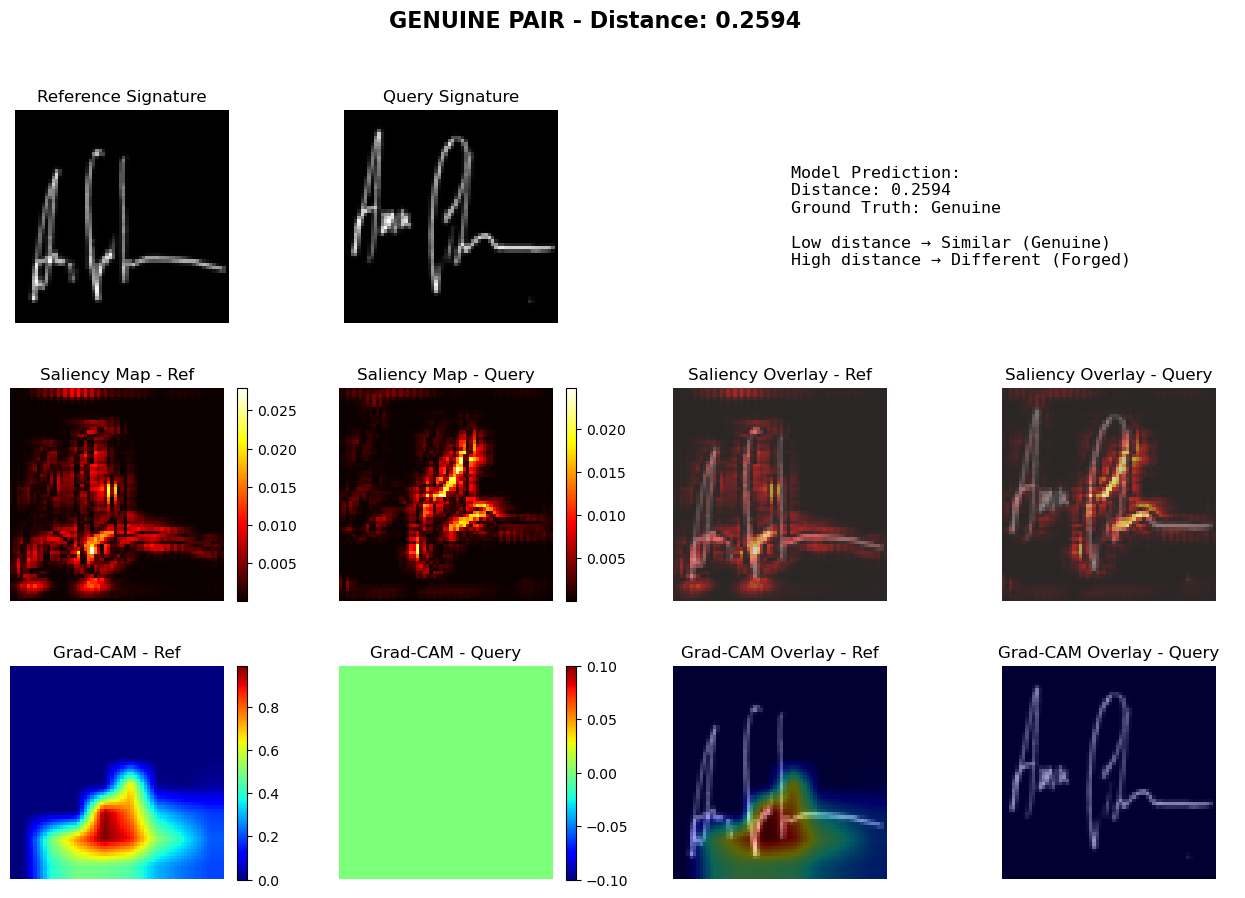

Processing pair 2/5...
Saved: manual_analysis/pair_1_genuine pair_dist0.266.png


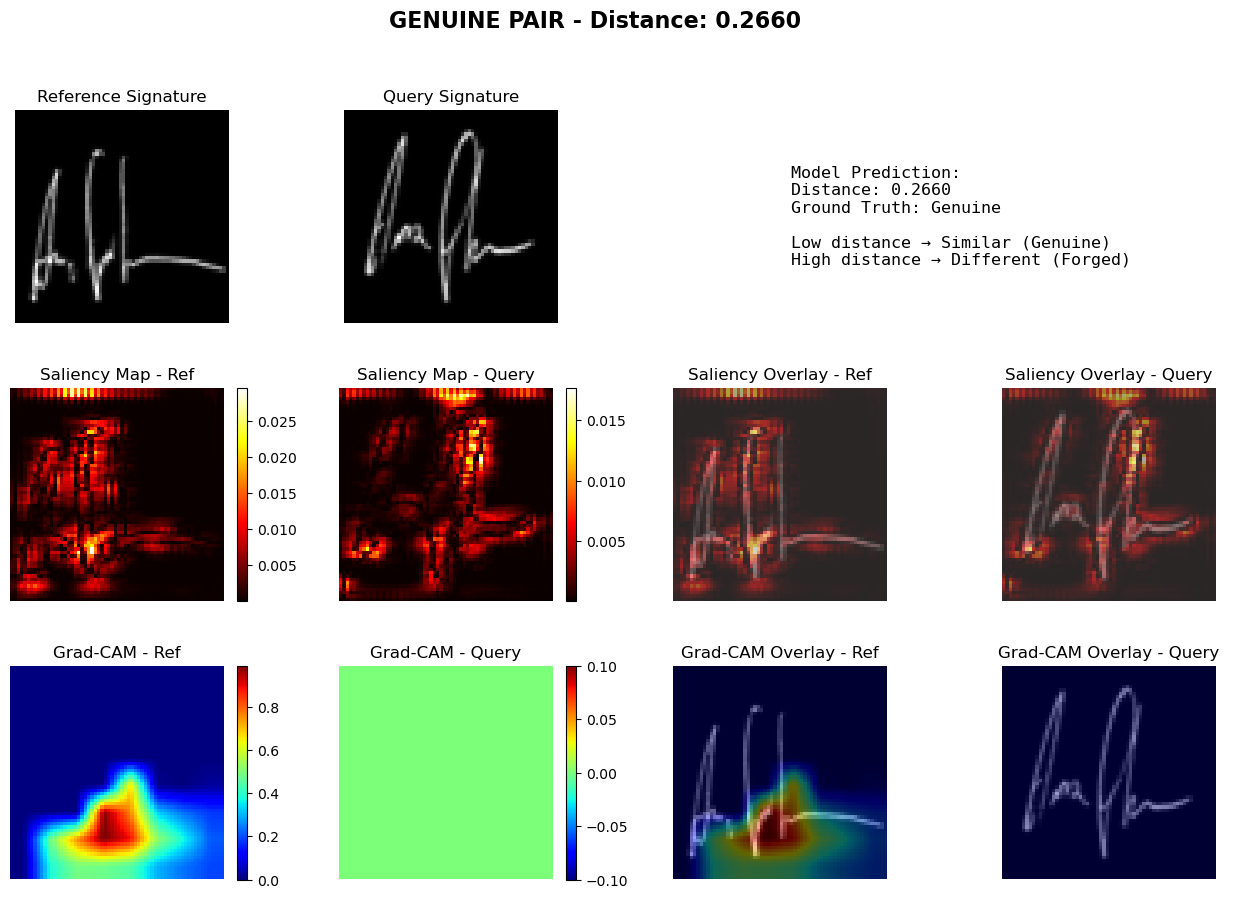

Processing pair 3/5...
Saved: manual_analysis/pair_2_genuine pair_dist0.193.png


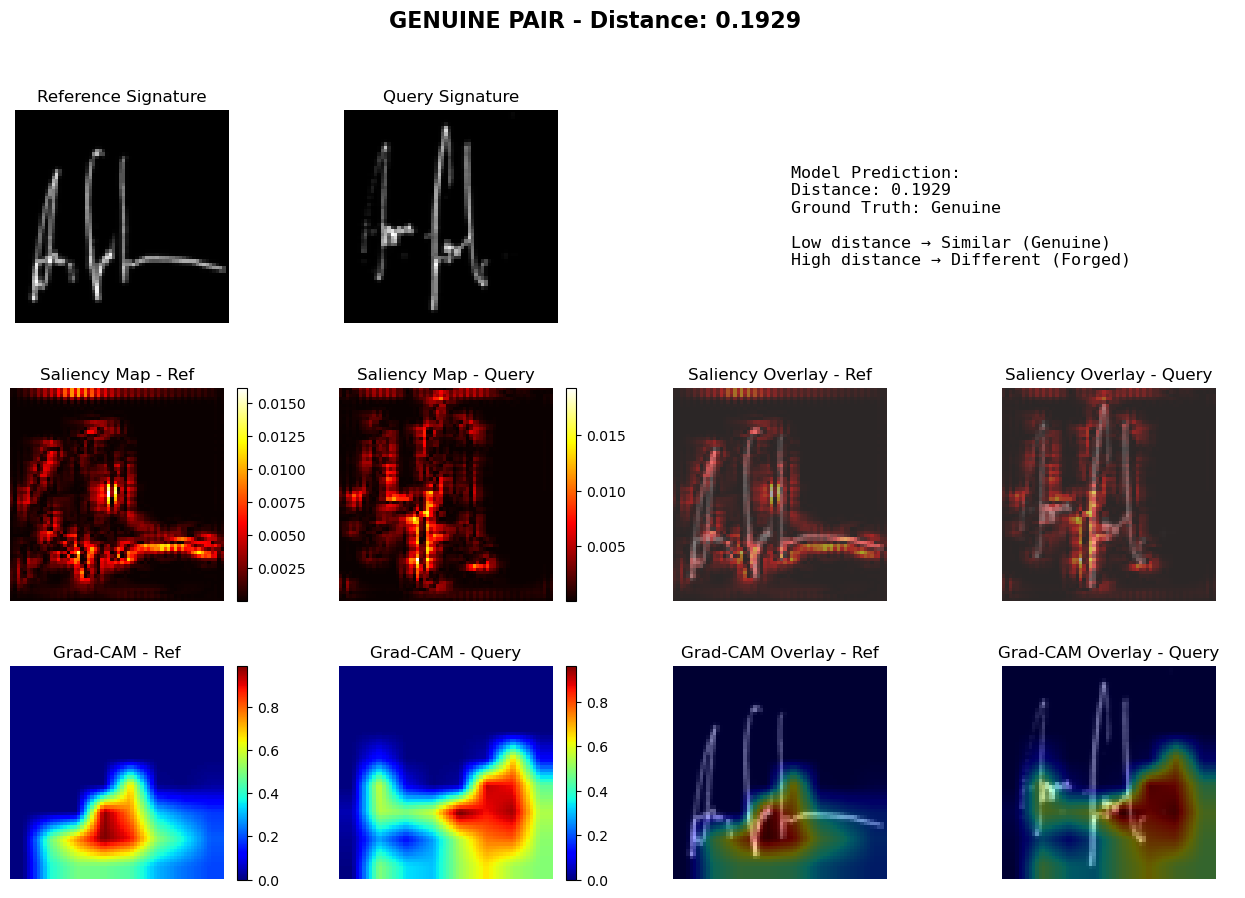

Processing pair 4/5...
Saved: manual_analysis/pair_3_genuine pair_dist0.209.png


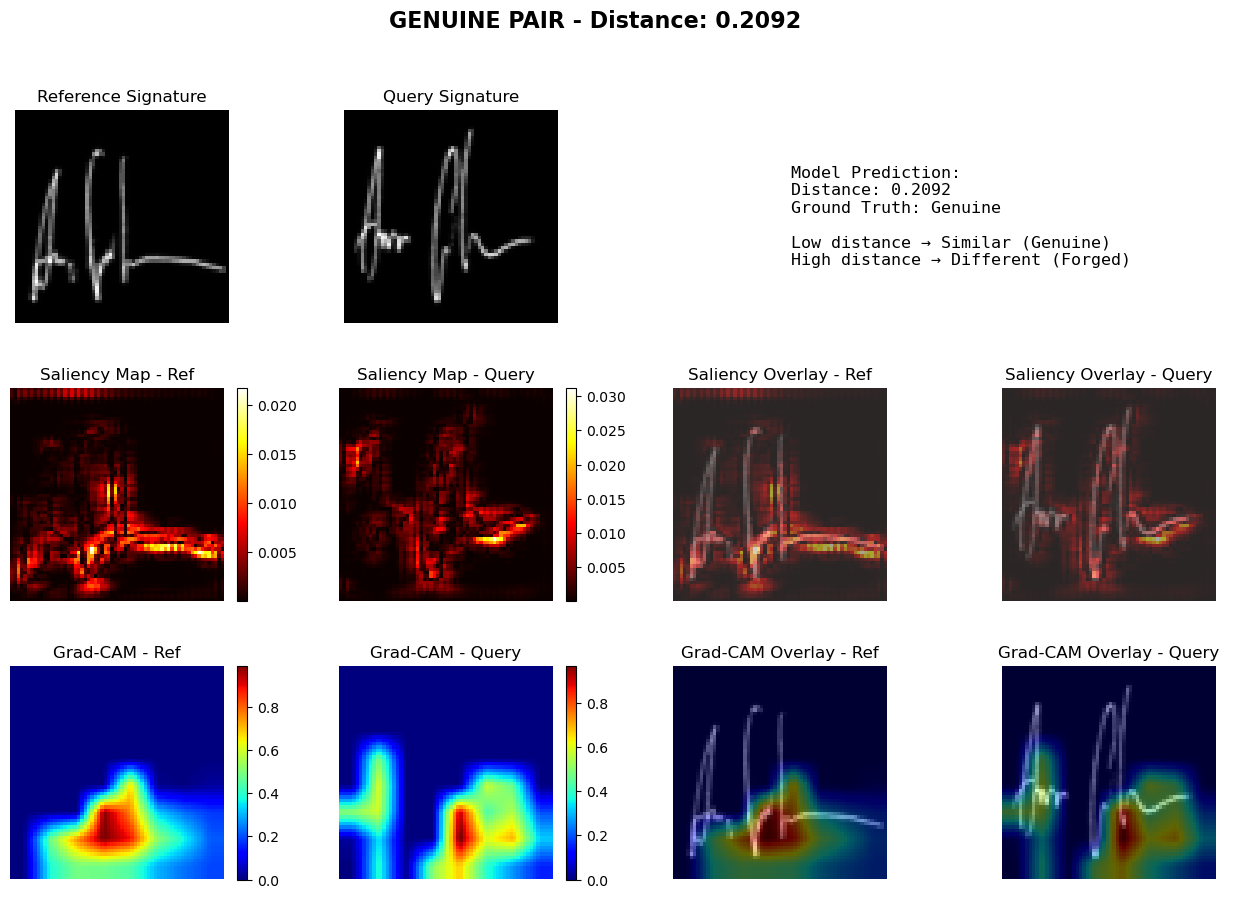

Processing pair 5/5...
Saved: manual_analysis/pair_4_genuine pair_dist0.198.png


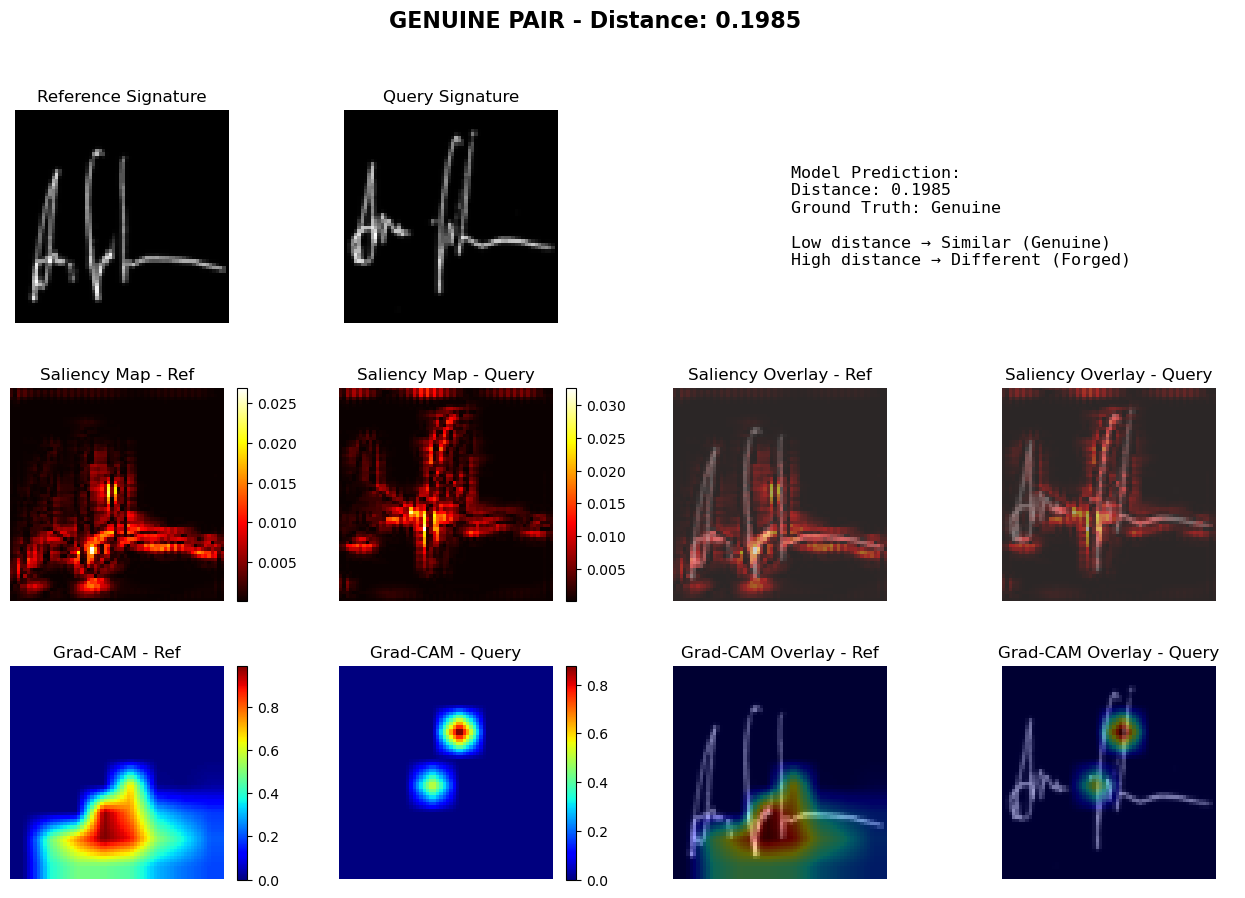

✓ Manual analysis complete
Visualizing feature maps...
Saved: feature_map_analysis/feature_maps_0.png


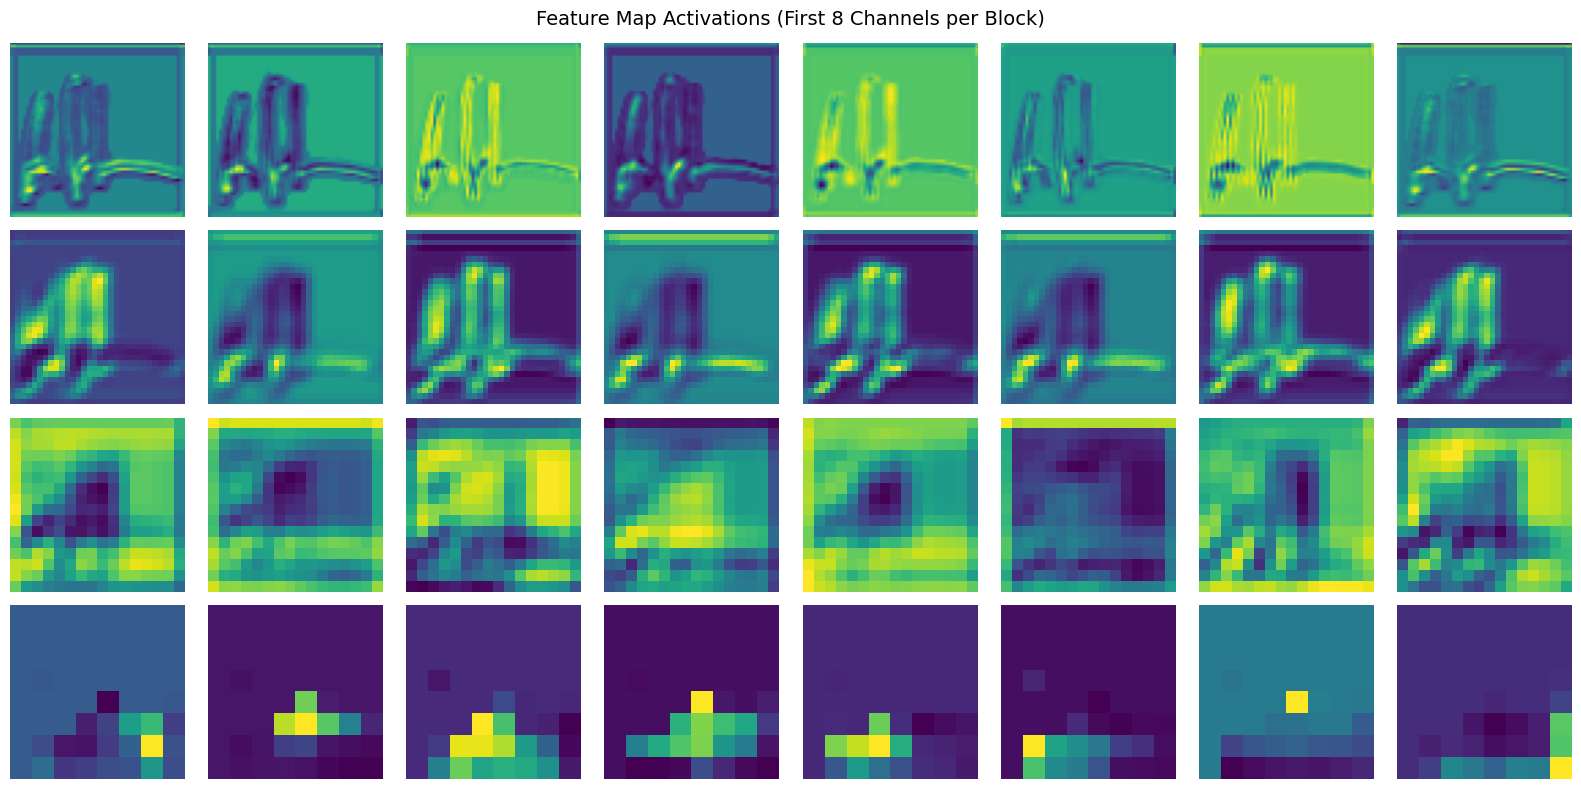

✓ Feature map visualization complete
Finding confidently wrong predictions...

Found 10 confidently wrong predictions
These are the cases where the model is most confused:

Pair 1/10: True=Genuine, Predicted=Forged, Distance=0.4850 (threshold=0.2552)
Saved: wrong_predictions/pair_0_genuine pair_dist0.485.png


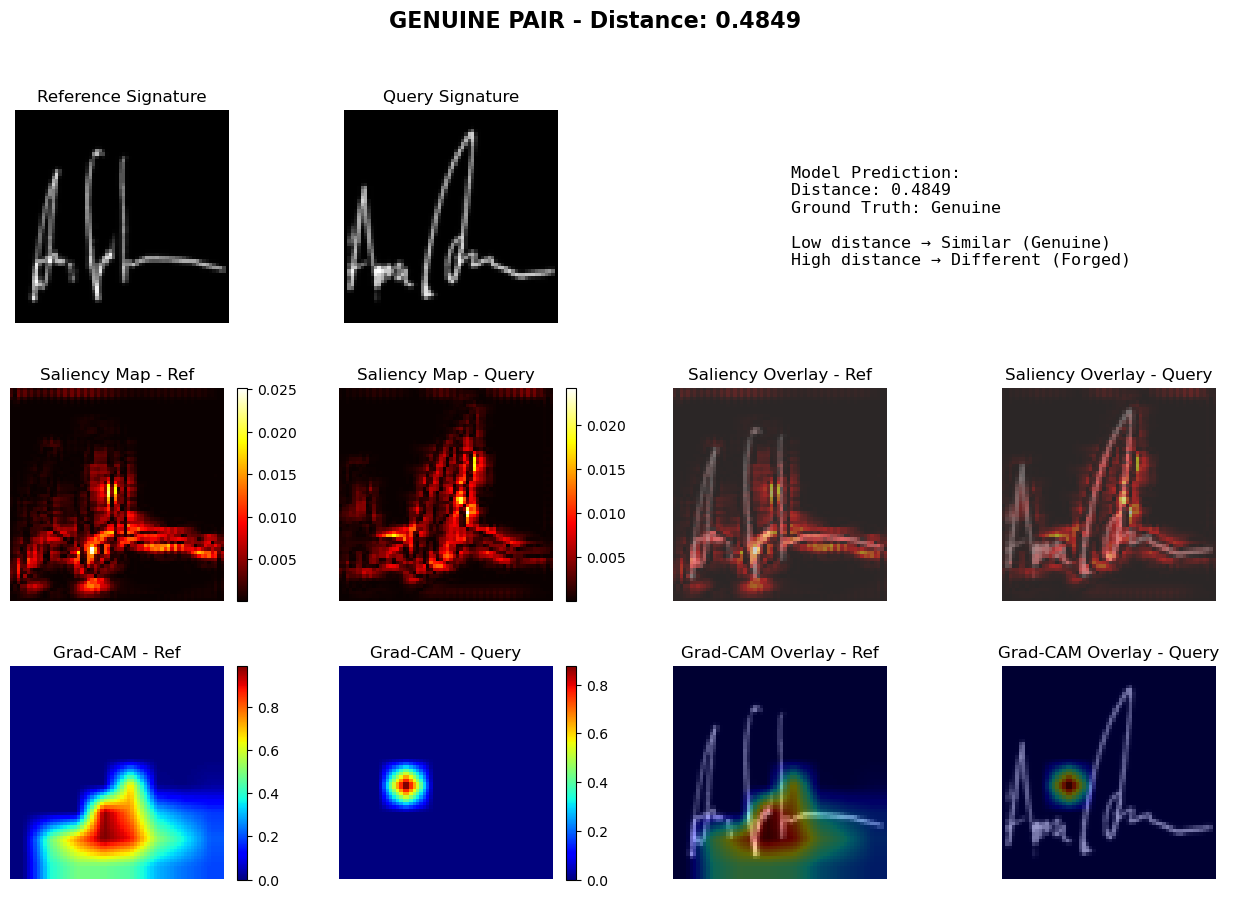

Pair 2/10: True=Genuine, Predicted=Forged, Distance=0.3921 (threshold=0.2552)
Saved: wrong_predictions/pair_1_genuine pair_dist0.392.png


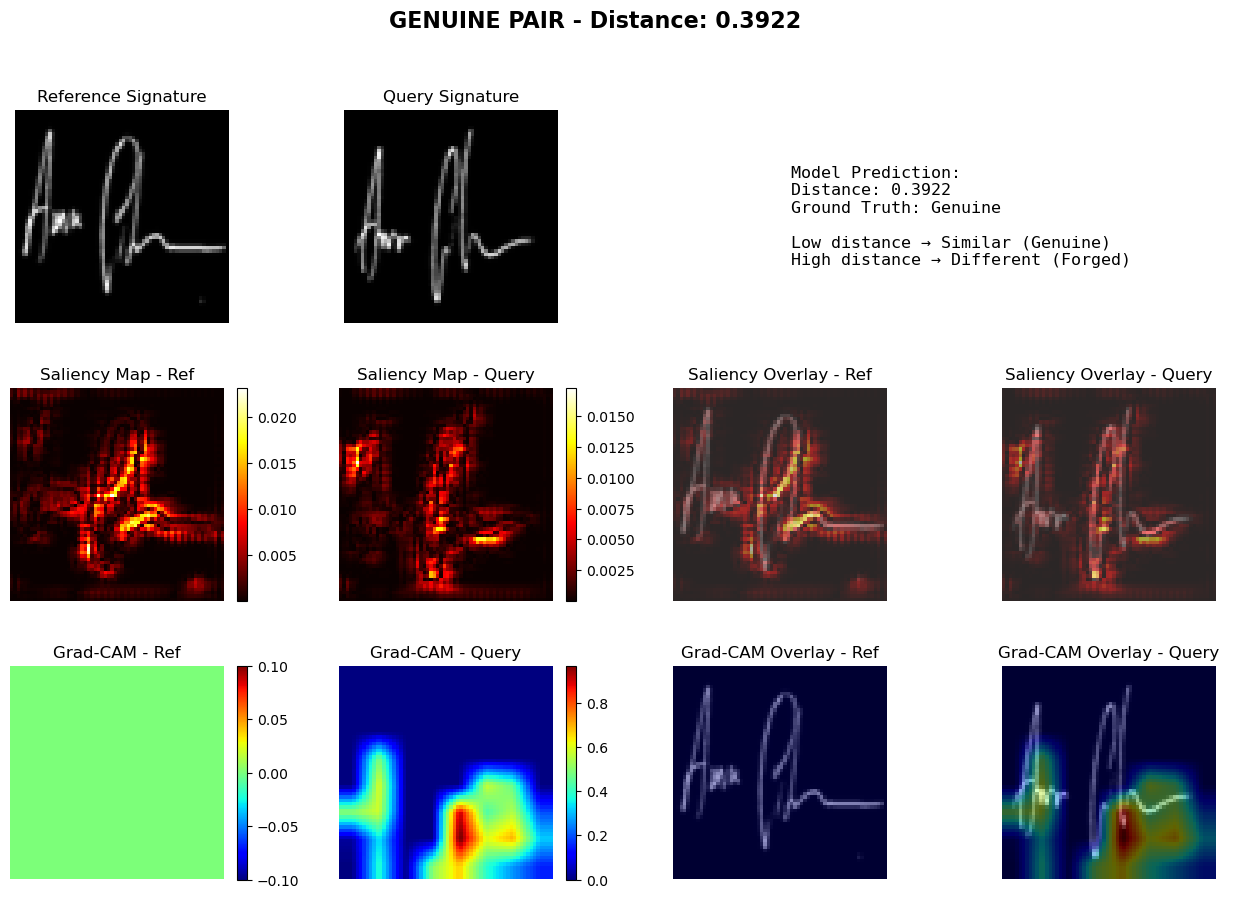

Pair 3/10: True=Genuine, Predicted=Forged, Distance=0.4487 (threshold=0.2552)
Saved: wrong_predictions/pair_2_genuine pair_dist0.449.png


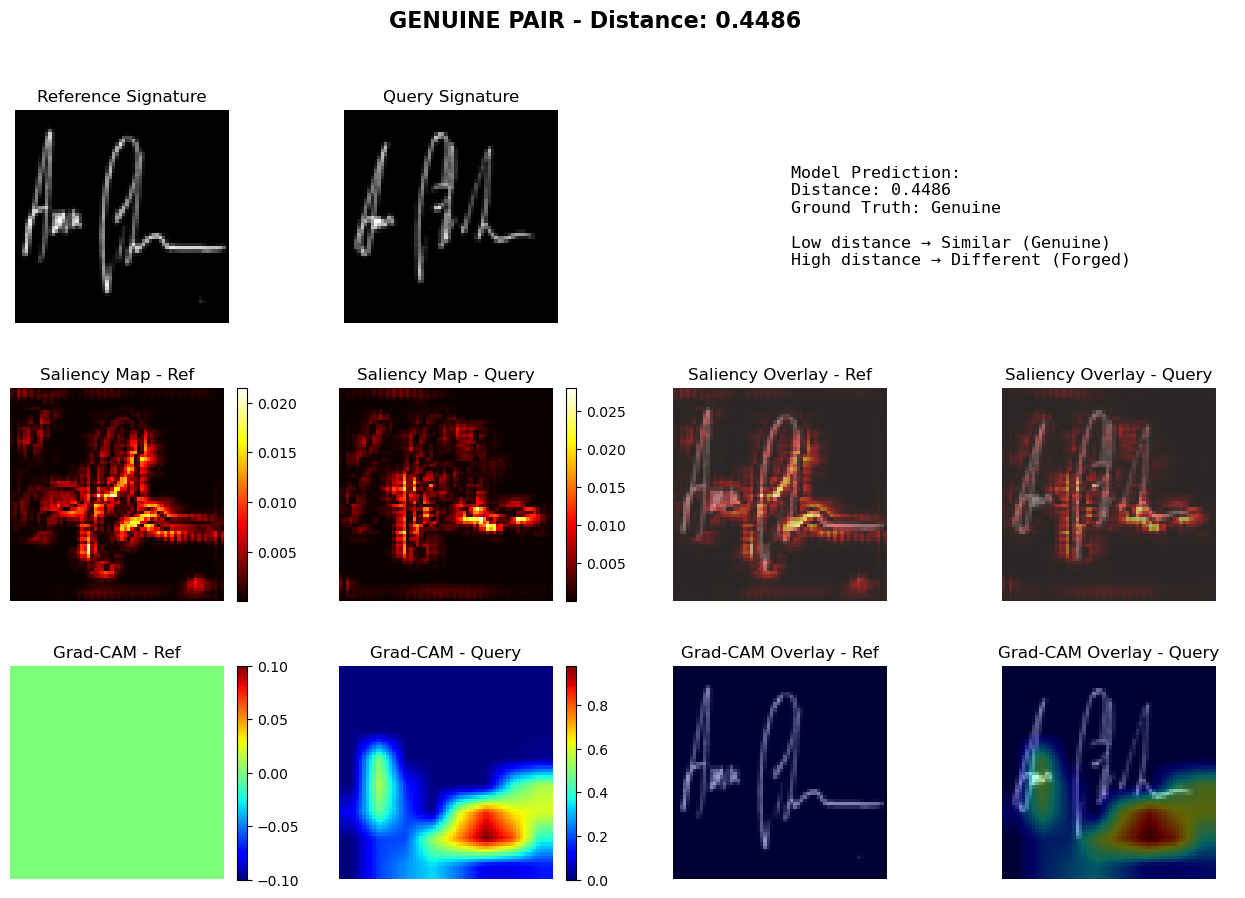

Pair 4/10: True=Genuine, Predicted=Forged, Distance=0.3693 (threshold=0.2552)
Saved: wrong_predictions/pair_3_genuine pair_dist0.369.png


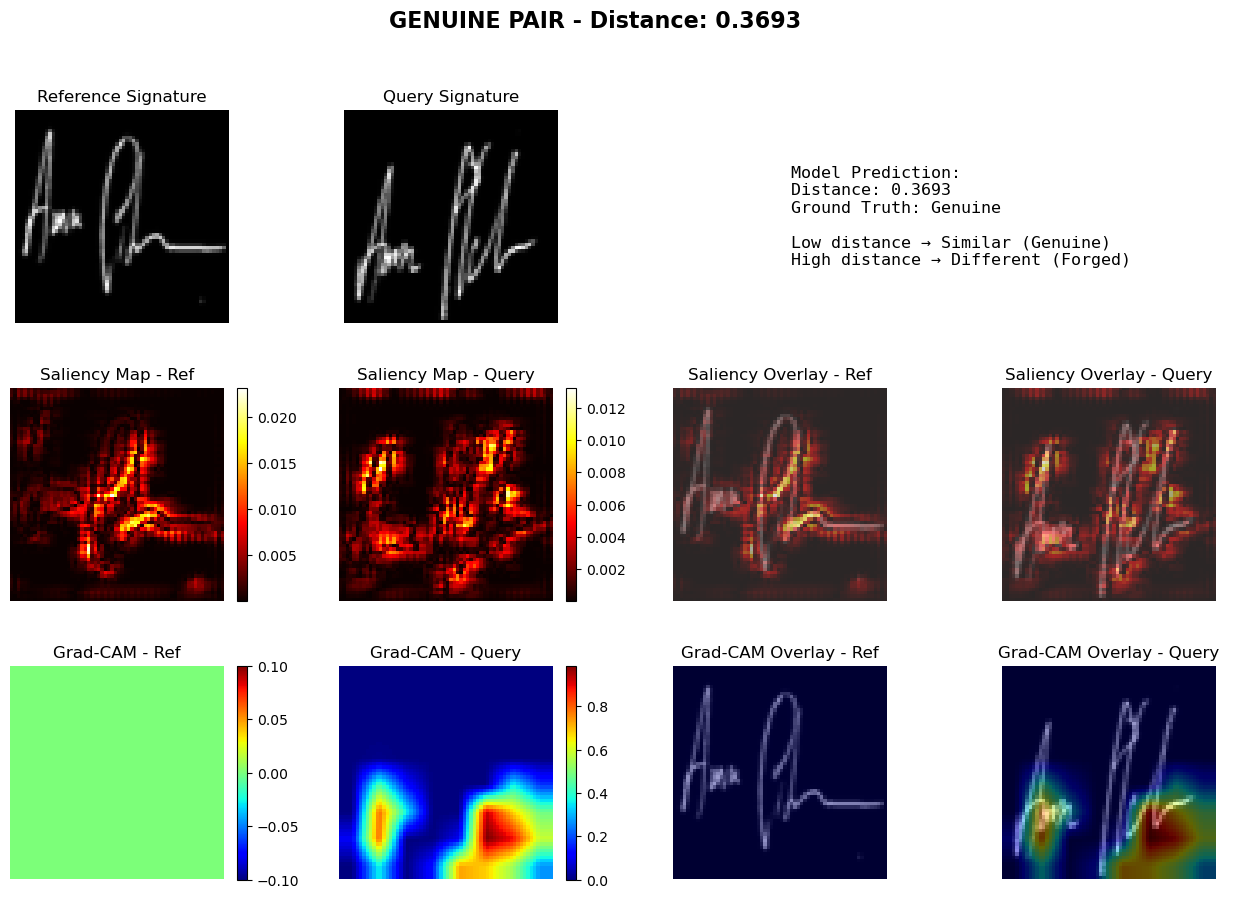

Pair 5/10: True=Genuine, Predicted=Forged, Distance=0.3867 (threshold=0.2552)
Saved: wrong_predictions/pair_4_genuine pair_dist0.387.png


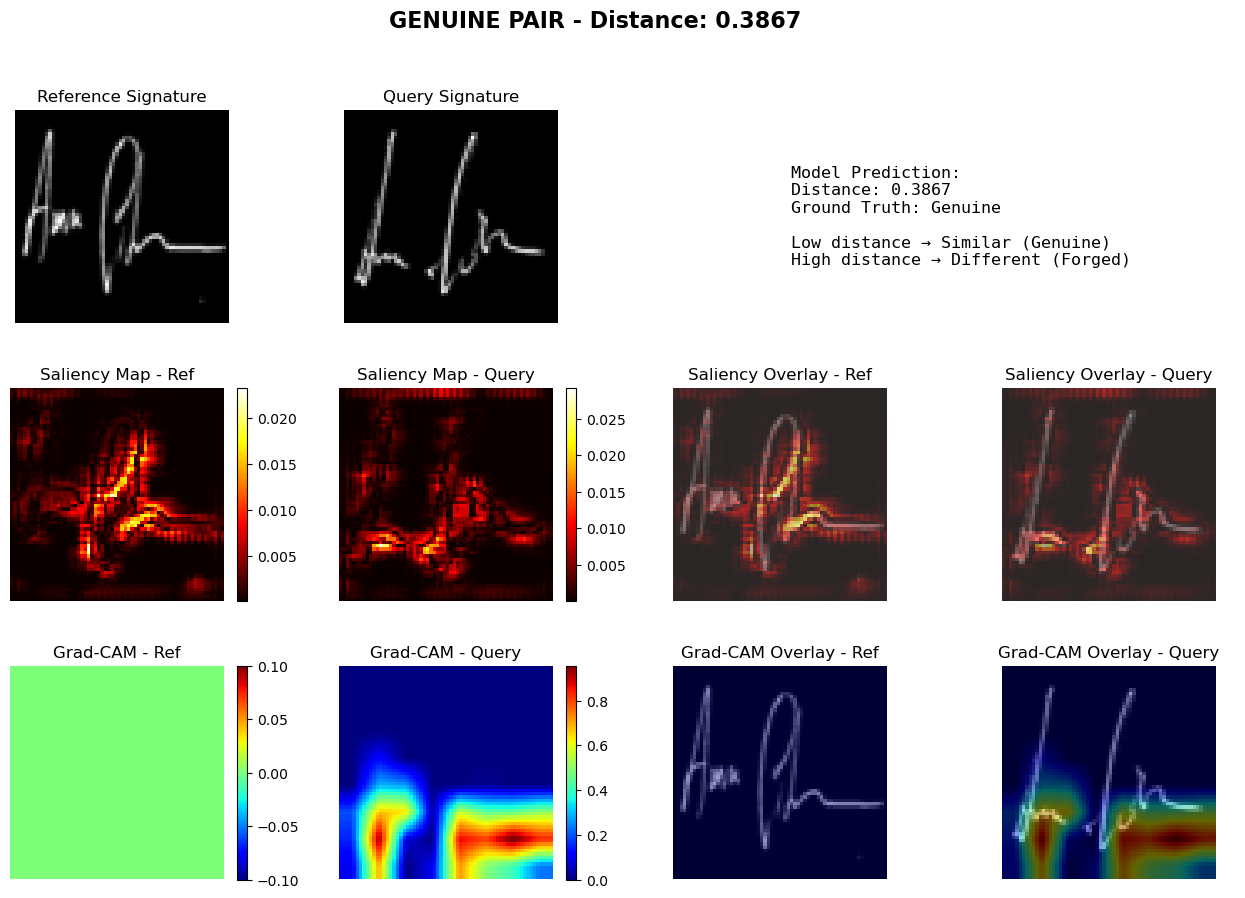

Pair 6/10: True=Genuine, Predicted=Forged, Distance=0.4359 (threshold=0.2552)
Saved: wrong_predictions/pair_5_genuine pair_dist0.436.png


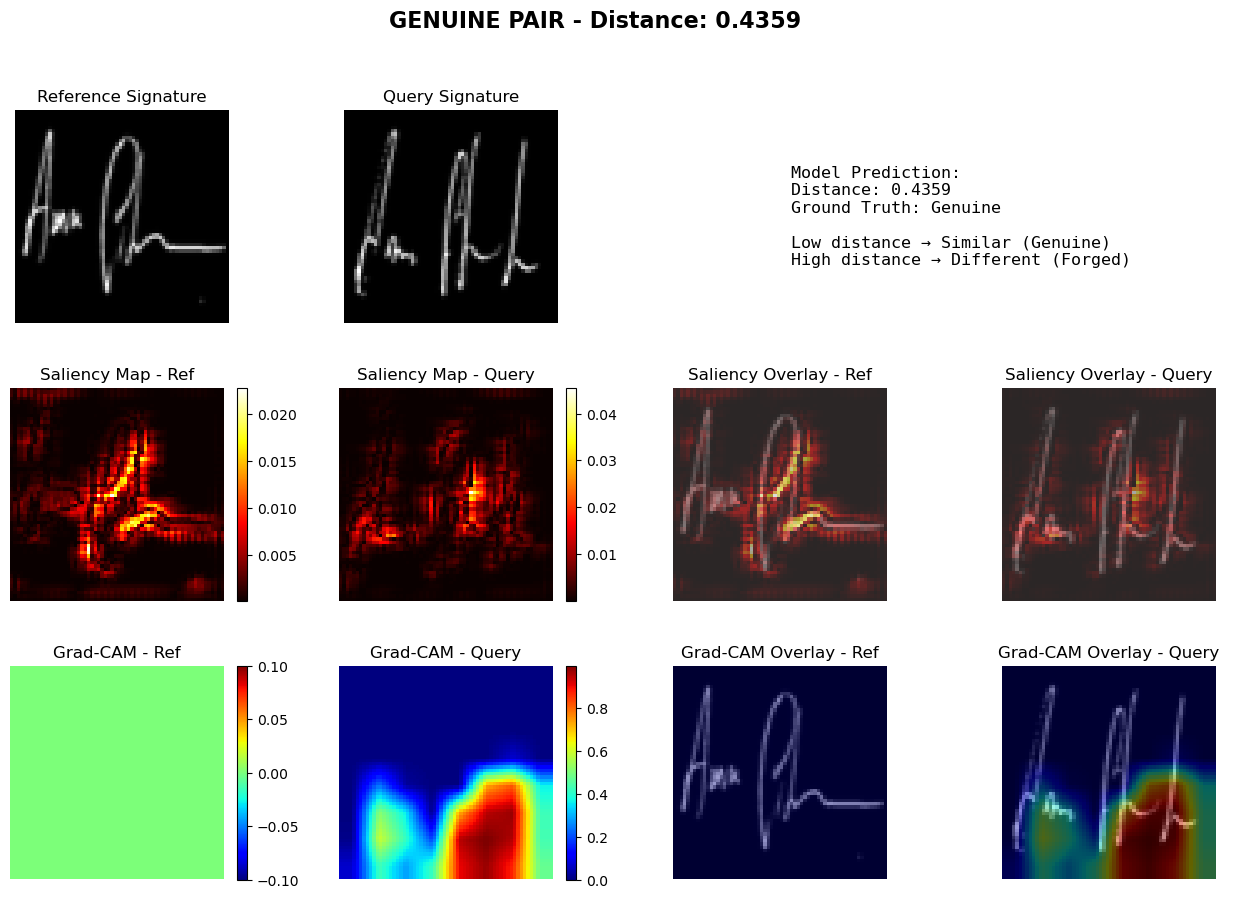

Pair 7/10: True=Genuine, Predicted=Forged, Distance=0.3875 (threshold=0.2552)
Saved: wrong_predictions/pair_6_genuine pair_dist0.388.png


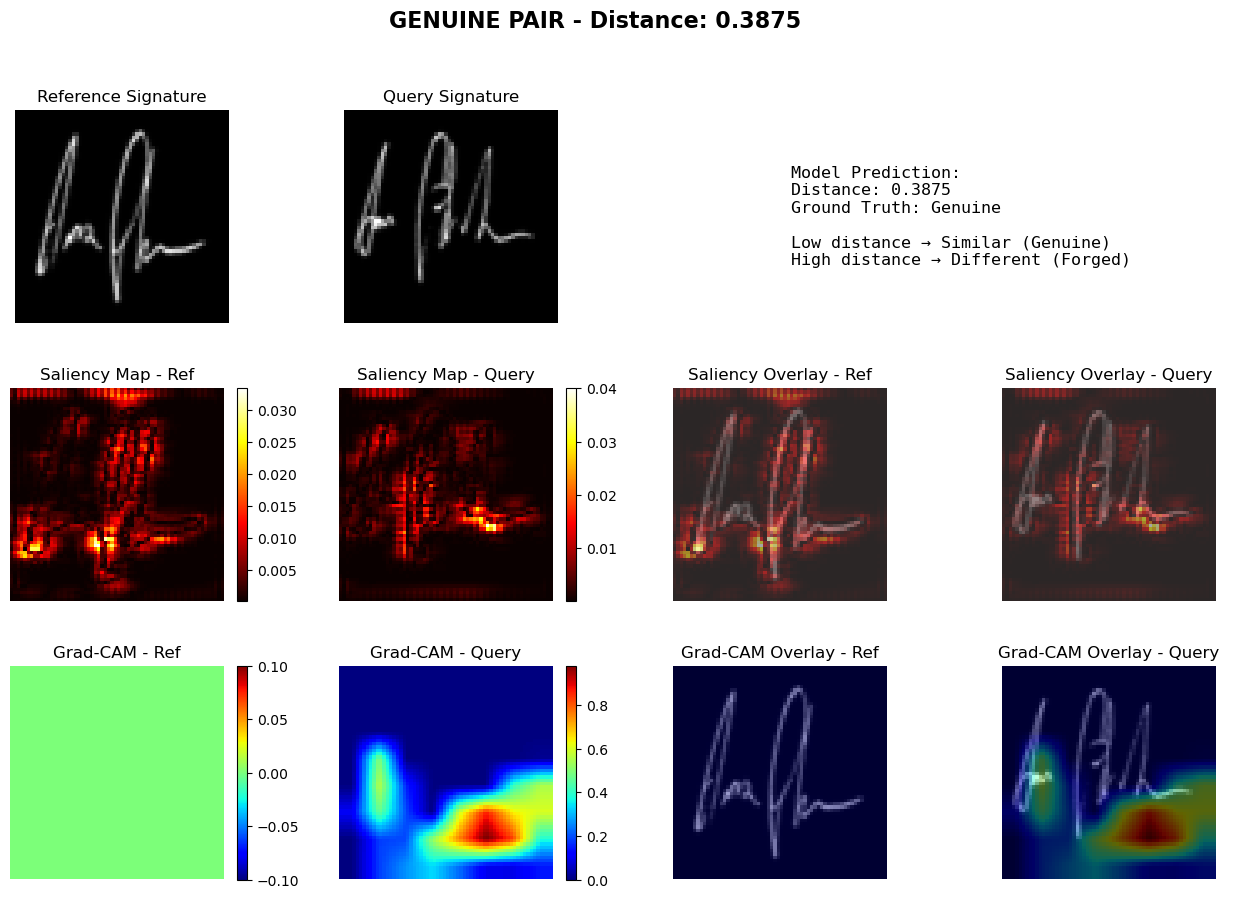

Pair 8/10: True=Genuine, Predicted=Forged, Distance=0.3600 (threshold=0.2552)
Saved: wrong_predictions/pair_7_genuine pair_dist0.360.png


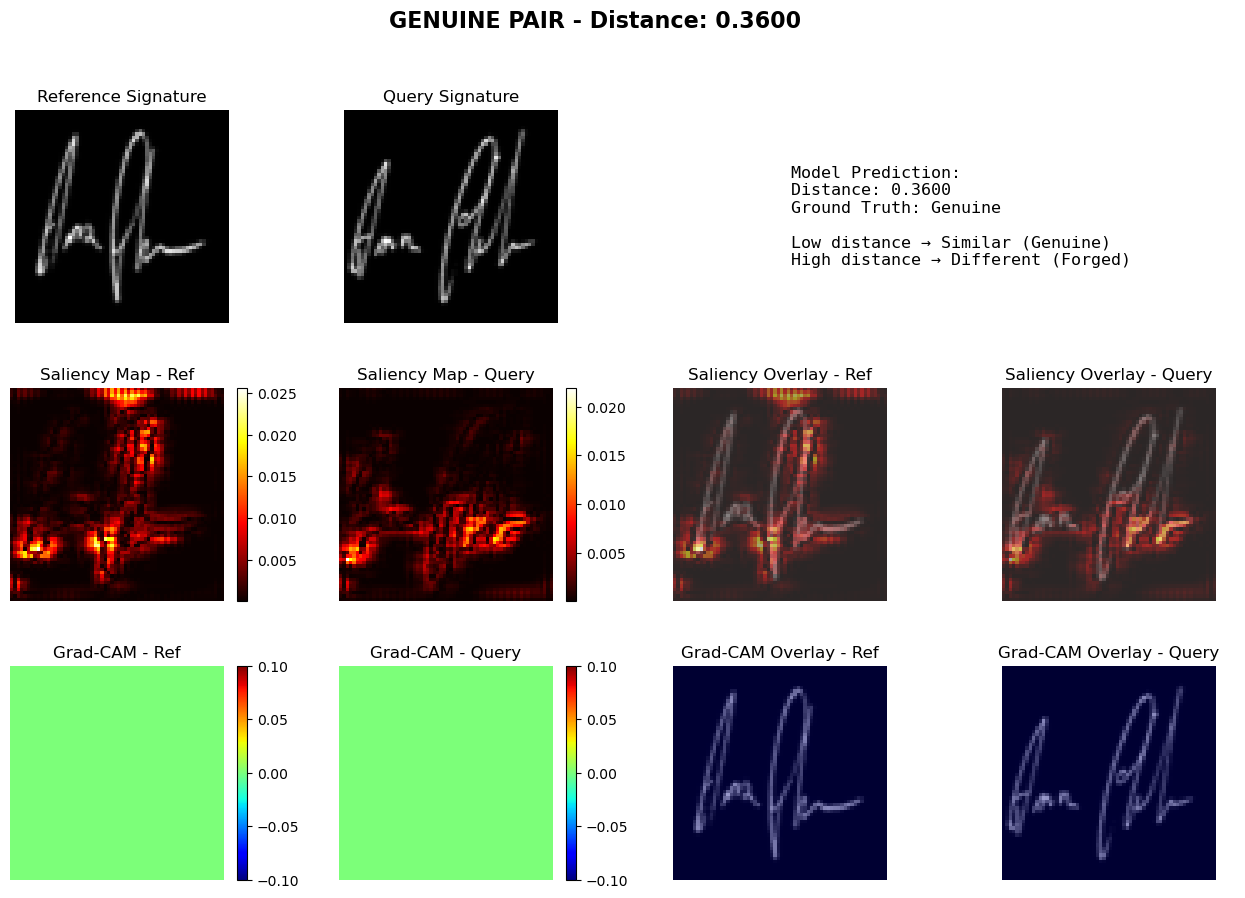

Pair 9/10: True=Genuine, Predicted=Forged, Distance=0.4078 (threshold=0.2552)
Saved: wrong_predictions/pair_8_genuine pair_dist0.408.png


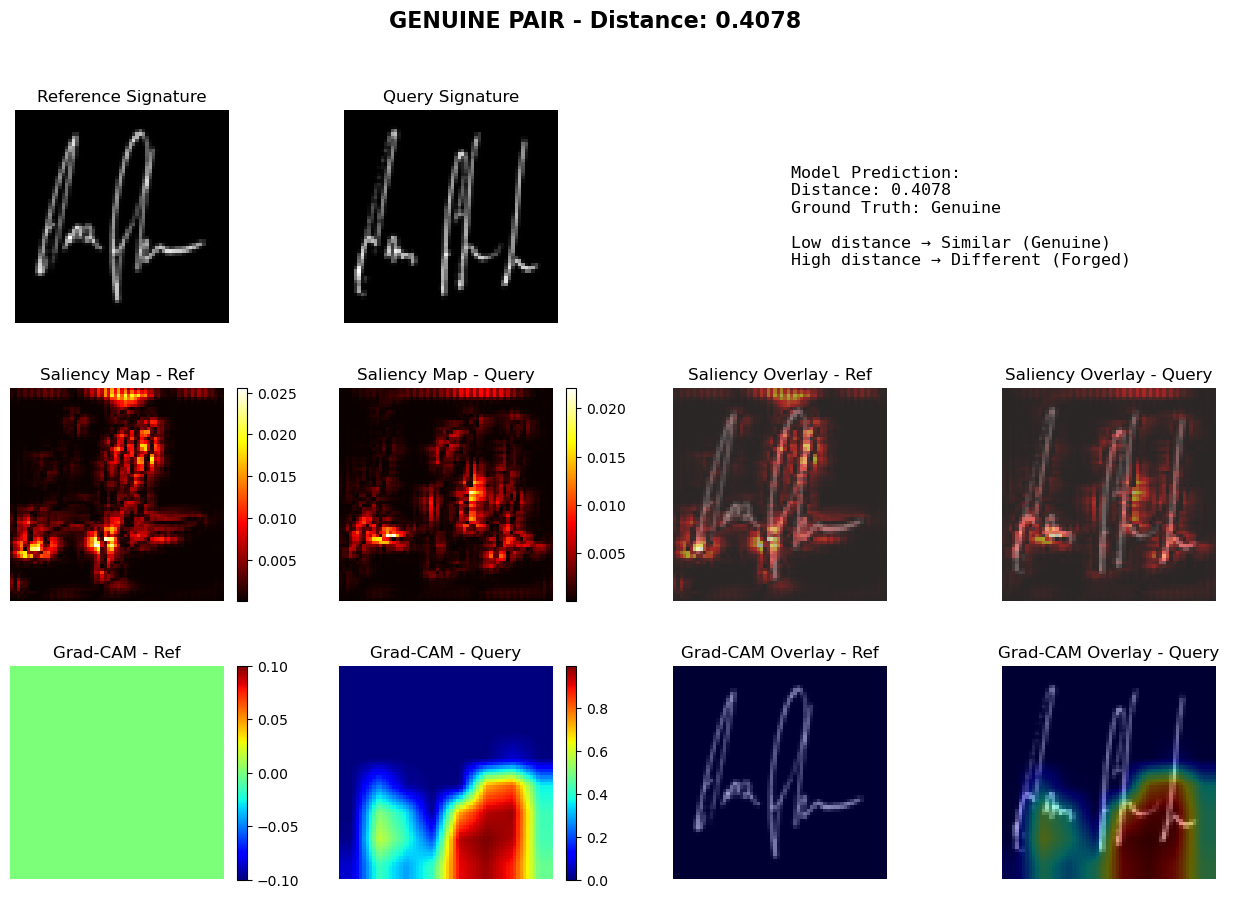

Pair 10/10: True=Genuine, Predicted=Forged, Distance=0.4454 (threshold=0.2552)
Saved: wrong_predictions/pair_9_genuine pair_dist0.445.png


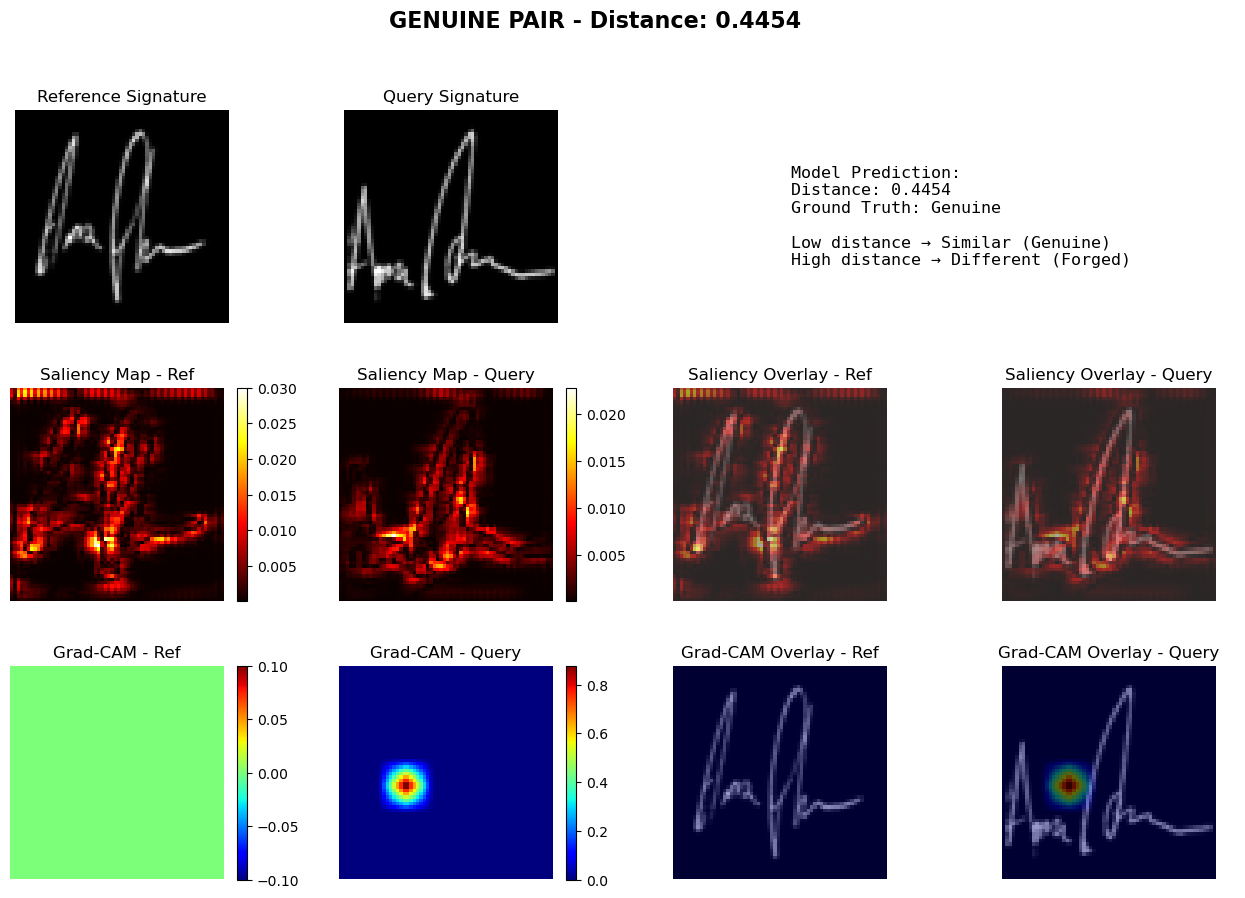


✓ Wrong predictions analysis complete



Computing saliency maps:   2%|█▍                                                        | 2/83 [00:14<09:56,  7.36s/it]



✓ Collected 50 genuine and 50 forged saliency maps
Average saliency map shapes: genuine=(64, 64), forged=(64, 64)


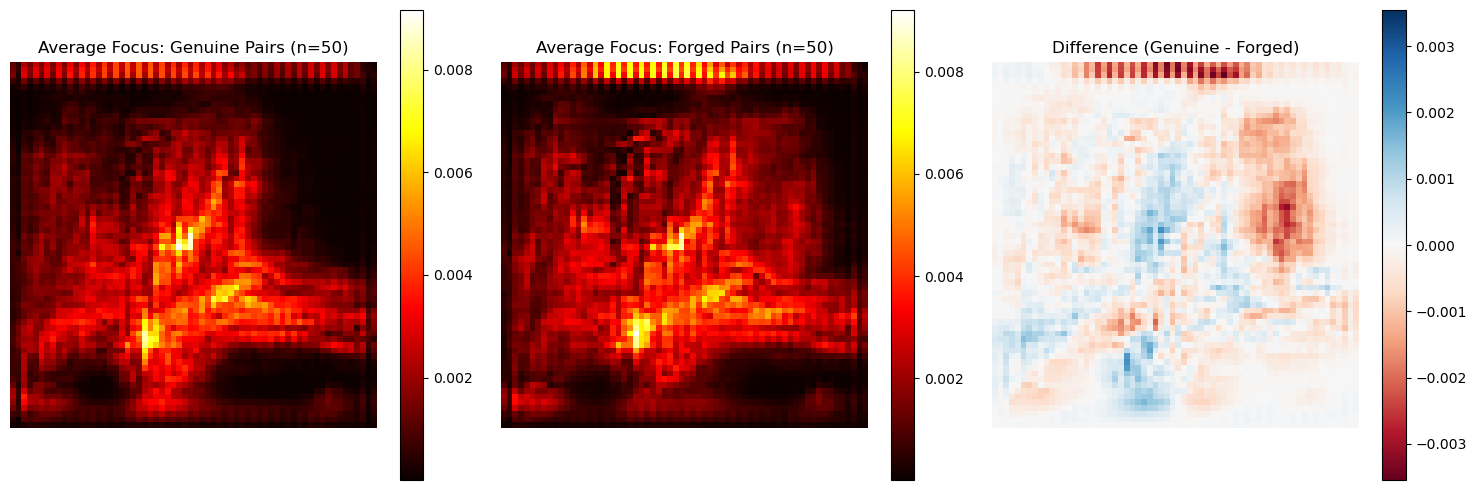

✓ Saved average_saliency_comparison.png

FOCUS STATISTICS

Genuine Pairs:
  Center focus: 0.0029
  Edge focus: 0.0011
  Center/Edge ratio: 2.54

Forged Pairs:
  Center focus: 0.0029
  Edge focus: 0.0014
  Center/Edge ratio: 2.14

INTERPRETATION:
✓ EXCELLENT: Model focuses on signature content (center)
✓ GOOD: Consistent behavior between genuine and forged pairs

Detailed Guidelines:
  • Center/Edge ratio > 2.0: Model focuses on signature content (GOOD)
  • Center/Edge ratio < 1.5: Model may be learning image artifacts (BAD)
  • Similar ratios for genuine/forged: Consistent behavior (GOOD)
  • Very different ratios: Model uses different strategies (investigate)

✓ Statistical analysis complete


In [95]:
# ==============================================================================
# SALIENCY MAP ANALYSIS - CLEAN VERSION (NO REDUNDANT CODE)
# ==============================================================================

# ─── Cell 1: Import the visualization module ──────────────────────────────
import saliency_visualization
importlib.reload(saliency_visualization)
from saliency_visualization import SaliencyVisualizer, analyze_model_focus

# ─── Cell 2: Quick Test (Run this first!) ─────────────────────────────────
print("Testing saliency computation on one pair...")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

visualizer = SaliencyVisualizer(model, device)

for img1, img2, labels in test_dataloader:
    try:
        sal1, sal2, dist = visualizer.compute_saliency(
            img1[0:1].clone(), 
            img2[0:1].clone(), 
            labels[0].item()
        )
        print(f"✓ Success! Saliency shapes: {sal1.shape}, {sal2.shape}")
        print(f"  Distance: {dist:.4f}")
        print(f"  Label: {labels[0].item()}")
        break
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        break

# ─── Cell 3: Run comprehensive analysis ───────────────────────────────────
"""
Visualize multiple genuine and forged pairs to see model behavior
"""

print("\nStarting comprehensive saliency map analysis...")
analyze_model_focus(
    model=model,
    dataloader=test_dataloader,
    device=device,
    num_samples=5,  # Start small, increase to 10-20 later
    save_dir='saliency_outputs'
)

# ─── Cell 4: Statistical Focus Analysis ───────────────────────────────────
"""
Quantify WHERE the model focuses (center vs edges) across many samples
This is the MOST IMPORTANT diagnostic
"""

visualizer = SaliencyVisualizer(model, device)

genuine_saliency_maps = []
forged_saliency_maps = []
num_analyze = 50  # Analyze 50 pairs of each type

print(f"\nCollecting saliency maps for {num_analyze} genuine and {num_analyze} forged pairs...")

genuine_count = 0
forged_count = 0

for img1_array, img2, labels in tqdm(test_dataloader, desc="Computing saliency"):
    if isinstance(img1_array, list):
        img1 = img1_array[0]
    else:
        img1 = img1_array
    
    for i in range(len(labels)):
        if genuine_count >= num_analyze and forged_count >= num_analyze:
            break
        
        label = labels[i].item()
        
        try:
            sal1, sal2, dist = visualizer.compute_saliency(
                img1[i:i+1].clone(), 
                img2[i:i+1].clone(), 
                label
            )
            
            if sal1.shape != (64, 64) or sal2.shape != (64, 64):
                continue
                
            avg_sal = (sal1 + sal2) / 2
            
            if label == 1 and genuine_count < num_analyze:
                genuine_saliency_maps.append(avg_sal)
                genuine_count += 1
            elif label == 0 and forged_count < num_analyze:
                forged_saliency_maps.append(avg_sal)
                forged_count += 1
                
        except Exception as e:
            continue
    
    if genuine_count >= num_analyze and forged_count >= num_analyze:
        break

print(f"✓ Collected {len(genuine_saliency_maps)} genuine, {len(forged_saliency_maps)} forged")

# Compute and visualize average focus
if len(genuine_saliency_maps) > 0 and len(forged_saliency_maps) > 0:
    genuine_avg = np.mean(genuine_saliency_maps, axis=0)
    forged_avg = np.mean(forged_saliency_maps, axis=0)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axes[0].imshow(genuine_avg, cmap='hot')
    axes[0].set_title(f'Average Focus: Genuine (n={len(genuine_saliency_maps)})')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(forged_avg, cmap='hot')
    axes[1].set_title(f'Average Focus: Forged (n={len(forged_saliency_maps)})')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])

    difference = genuine_avg - forged_avg
    vmax = max(abs(difference.min()), abs(difference.max()))
    im2 = axes[2].imshow(difference, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Difference (Genuine - Forged)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.savefig('average_saliency_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Compute statistics
    def compute_focus_stats(saliency_maps):
        center_vals, edge_vals = [], []
        for sal in saliency_maps:
            h, w = sal.shape
            center_mask = np.zeros_like(sal)
            center_mask[h//4:3*h//4, w//4:3*w//4] = 1
            center_vals.append(sal[center_mask == 1].mean())
            edge_vals.append(sal[center_mask == 0].mean())
        return {
            'center_mean': np.mean(center_vals),
            'edge_mean': np.mean(edge_vals),
            'ratio': np.mean(center_vals) / (np.mean(edge_vals) + 1e-8)
        }

    genuine_stats = compute_focus_stats(genuine_saliency_maps)
    forged_stats = compute_focus_stats(forged_saliency_maps)

    print("\n" + "="*60)
    print("FOCUS STATISTICS")
    print("="*60)
    print(f"\nGenuine Pairs:")
    print(f"  Center focus: {genuine_stats['center_mean']:.4f}")
    print(f"  Edge focus: {genuine_stats['edge_mean']:.4f}")
    print(f"  Center/Edge ratio: {genuine_stats['ratio']:.2f}")

    print(f"\nForged Pairs:")
    print(f"  Center focus: {forged_stats['center_mean']:.4f}")
    print(f"  Edge focus: {forged_stats['edge_mean']:.4f}")
    print(f"  Center/Edge ratio: {forged_stats['ratio']:.2f}")

    # Auto-interpretation
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    
    if genuine_stats['ratio'] > 2.0 and forged_stats['ratio'] > 2.0:
        print("✓ EXCELLENT: Model focuses on signature content")
    elif genuine_stats['ratio'] > 1.5 and forged_stats['ratio'] > 1.5:
        print("✓ GOOD: Model focuses on center")
    else:
        print("✗ WARNING: Model may learn edge artifacts")
    
    if abs(genuine_stats['ratio'] - forged_stats['ratio']) < 0.5:
        print("✓ GOOD: Consistent strategy")
    else:
        print("⚠️ WARNING: Different strategies for genuine vs forged")
        print(f"   → This explains accuracy issues with forgeries")
else:
    print("❌ Failed to collect saliency maps")

# ─── Cell 5: Analyze Wrong Predictions ────────────────────────────────────
"""
Find cases where model is confidently wrong - these reveal model weaknesses
"""

visualizer = SaliencyVisualizer(model, device)
confident_wrong_pairs = []

print("\nFinding confidently wrong predictions...")

with torch.no_grad():
    for img1, img2, labels in test_dataloader:
        img1 = img1.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        
        emb1 = model(img1)
        emb2 = model(img2)
        distances = F.pairwise_distance(emb1, emb2)
        
        try:
            threshold = optimal_threshold
        except NameError:
            threshold = 0.5
            
        predictions = (distances < threshold).float()
        
        for i in range(len(labels)):
            is_wrong = (predictions[i] != labels[i])
            confidence = abs(distances[i].item() - threshold)
            
            if is_wrong and confidence > 0.1:
                confident_wrong_pairs.append({
                    'img1': img1[i:i+1].clone().cpu(),
                    'img2': img2[i:i+1].clone().cpu(),
                    'label': labels[i].item(),
                    'distance': distances[i].item(),
                    'predicted': predictions[i].item()
                })
                
                if len(confident_wrong_pairs) >= 10:
                    break
        
        if len(confident_wrong_pairs) >= 10:
            break

print(f"\nFound {len(confident_wrong_pairs)} confidently wrong predictions")

if len(confident_wrong_pairs) == 0:
    print("✓ No confident mistakes - excellent!")
else:
    print("Visualizing confused cases...")
    for idx, pair in enumerate(confident_wrong_pairs[:5]):  # Show first 5
        true_label = "Genuine" if pair['label'] == 1 else "Forged"
        pred_label = "Genuine" if pair['predicted'] == 1 else "Forged"
        print(f"{idx+1}. True={true_label}, Pred={pred_label}, Dist={pair['distance']:.3f}")
        
        visualizer.visualize_pair(
            pair['img1'], pair['img2'], pair['label'],
            save_path='wrong_predictions', pair_idx=idx
        )

# ─── Cell 6: Feature Map Visualization (Optional) ─────────────────────────
"""
See what intermediate layers learn - useful for architecture debugging
"""

visualizer = SaliencyVisualizer(model, device)

for img1, img2, labels in test_dataloader:
    print("Visualizing feature maps from block1 to block4...")
    visualizer.visualize_feature_maps(
        img1[0:1].clone(),
        save_path='feature_maps',
        img_idx=0
    )
    break

print("\n✓ All analysis complete!")

Validation Accuracy (optimal threshold=0.295): 0.7058
Accuracy:  0.7058
Precision: 0.6719
Recall:    0.7590
F1-score:  0.7128
AUC:       0.7803

Distance Statistics:
  Genuine mean: 0.211 ± 0.149
  Forged mean:  0.451 ± 0.278


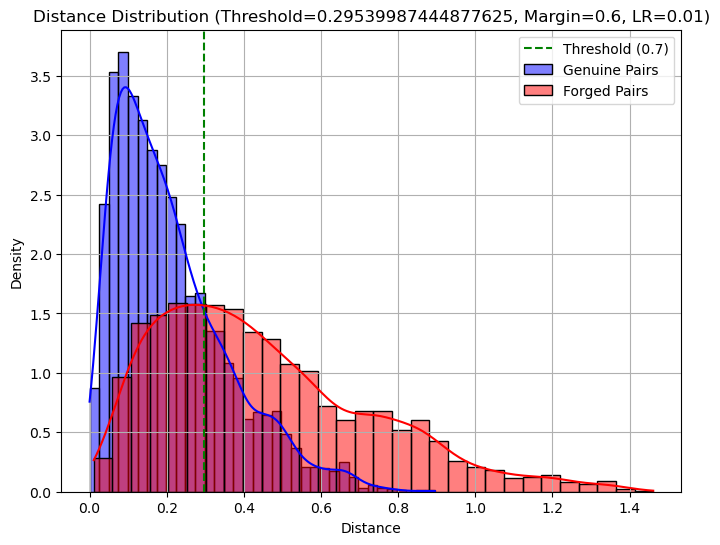

In [23]:
val_losses = []
distance_all = []
labels_all = []
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
with torch.no_grad():
    for img1_array, img2, labels in test_dataloader:
        # Use only first reference
        img1 = img1_array.to(device, non_blocking=True)
        #img1 = img1_array.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
    
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
    
        distance = F.pairwise_distance(emb1, emb2)
        distance_all.append(distance)
        labels_all.append(labels)
    
        val_batch_loss = criterion(emb1, emb2, labels)
        val_losses.append(val_batch_loss.item())

# Aggregate
distance_all = torch.cat(distance_all)
labels_all = torch.cat(labels_all)
avg_val_loss = sum(val_losses) / len(val_losses)

# ─── Threshold tuning (FIXED!) ───────────────────────────────
y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!

# Method 1: Simple negation approach (recommended)
similarity_scores = -distance_all.cpu().numpy()
fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)
y_pred_optimal = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

print(f"Validation Accuracy (optimal threshold={optimal_threshold:.3f}): {accuracy_score(y_true, y_pred_optimal):.4f}")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_true, similarity_scores):.4f}")
print(f"\nDistance Statistics:")
print(f"  Genuine mean: {distance_all[labels_all==1].mean():.3f} ± {distance_all[labels_all==1].std():.3f}")
print(f"  Forged mean:  {distance_all[labels_all==0].mean():.3f} ± {distance_all[labels_all==0].std():.3f}")
indices = np.random.permutation(len(labels_all))
distance_np = distance_all[indices].cpu().numpy()
labels_np = labels_all[indices].cpu().numpy()
distance_genuine = distance_np[labels_np == 1].tolist()
distance_forged = distance_np[labels_np == 0].tolist()

plt.figure(figsize=(8, 6))
sns.histplot(distance_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
sns.histplot(distance_forged, color='red', label='Forged Pairs', kde=True, stat='density')
plt.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.title(f'Distance Distribution (Threshold={optimal_threshold}, Margin={margin}, LR={lr})')
plt.legend()
plt.grid(True)
# plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
plt.show()  # Display the plot
plt.close()